In [1]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
# import scipy.stats as stats
# import statsmodels.api as sm
import miceforest as mf
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error


from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


from tqdm import tqdm
import os



from tensorflow.keras.layers import Lambda, Dropout, Concatenate
from tensorflow.keras import losses
from tensorflow.keras import backend as K
from sklearn.metrics import mean_absolute_error, mean_squared_error as sk_mse




from sklearn.neural_network import MLPRegressor
from sklearn.impute import SimpleImputer
import warnings
import time
warnings.filterwarnings('ignore')


from sklearn.base import BaseEstimator, TransformerMixin

import random
from sklearn.model_selection import KFold
from scipy.stats import ks_2samp

from sklearn.ensemble import RandomForestRegressor


import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import datetime
import matplotlib.pyplot as plt
import os
import sys

2026-03-01 19:51:41.526392: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-01 19:51:41.689425: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-01 19:51:41.769110: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-01 19:51:42.207723: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-01 19:51:45.885848: W tensorflow/compiler/tf2

# Data Import + only Baseline

In [2]:
# Read the CSV file - linked file  
file_path = "Merged_REDCap.xlsx" 
df = pd.read_excel(file_path)
df

,id,operation_date,redcap_event_name,postop_comp,ComplicationDate,los,readmission_30d,DischargeDate,dob,qol_date,...,a_e1,a_e2,a_e3,a_e4,a_e5,a_e6,a_e7,a_c6,a_c2,a_act11
0,1,NaT,baseline_arm_1,NaN,NaT,NaN,NaN,NaT,2049-08-04,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaT,5_years_postop_arm_1,NaN,NaT,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,NaT,baseline_arm_1,NaN,NaT,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2006-09-13,surgery_arm_1,NaN,NaT,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,NaT,surgery_arm_1,NaN,NaT,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15002,1788,NaT,baseline_arm_1,NaN,NaT,NaN,NaN,NaT,2047-03-23,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15003,1788,NaT,baseline_arm_1,NaN,NaT,NaN,NaN,NaT,NaT,2025-06-09,...,0.0,0.0,0.0,1.0,0.0,2.0,0.0,2.0,2.0,0.0
15004,1788,NaT,baseline_arm_1,NaN,NaT,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15005,1789,NaT,baseline_arm_1,NaN,NaT,NaN,NaN,NaT,2045-08-19,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df[df['id']==1770]

,id,operation_date,redcap_event_name,postop_comp,ComplicationDate,los,readmission_30d,DischargeDate,dob,qol_date,...,a_e1,a_e2,a_e3,a_e4,a_e5,a_e6,a_e7,a_c6,a_c2,a_act11
14928,1770,NaT,baseline_arm_1,NaN,NaT,NaN,NaN,NaT,1982-10-12,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14929,1770,NaT,preoperative_arm_1,NaN,NaT,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14930,1770,NaT,1_month_postop_arm_1,NaN,NaT,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14931,1770,NaT,5_years_postop_arm_1,NaN,NaT,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14932,1770,NaT,baseline_arm_1,NaN,NaT,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14933,1770,NaT,preoperative_arm_1,NaN,NaT,NaN,NaN,NaT,NaT,2025-02-24,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,3.0
14934,1770,2025-03-14,surgery_arm_1,NaN,NaT,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14935,1770,NaT,surgery_arm_1,NaN,NaT,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14936,1770,NaT,1_month_postop_arm_1,NaN,NaT,NaN,NaN,NaT,NaT,2025-04-28,...,1.0,0.0,0.0,2.0,1.0,0.0,0.0,1.0,2.0,0.0


                              ge1         ge2         ge3         ge4  \
1_month_postop_arm_1    43.703704   43.555556   44.740741   44.000000   
1_year_postop_arm_1      5.729167    5.729167    7.291667    5.208333   
2_years_postop_arm_1     3.703704    3.703704    3.703704    3.703704   
3_months_postop_arm_1    2.684564    4.697987    4.026846    3.355705   
3_years_postop_arm_1     6.250000    8.750000    7.500000    6.250000   
4_years_postop_arm_1     4.000000    6.000000    4.000000    4.000000   
5_years_postop_arm_1    94.906512   94.970986   94.906512   94.906512   
6_months_postop_arm_1    3.157895    3.684211    3.684211    4.210526   
baseline_arm_1          47.038917   48.505358   50.479413   47.828539   
preoperative_arm_1      73.896104   73.961039   74.090909   73.831169   
surgery_arm_1          100.000000  100.000000  100.000000  100.000000   

                              ge5         ge6  
1_month_postop_arm_1    43.851852   43.703704  
1_year_postop_arm_1      6.

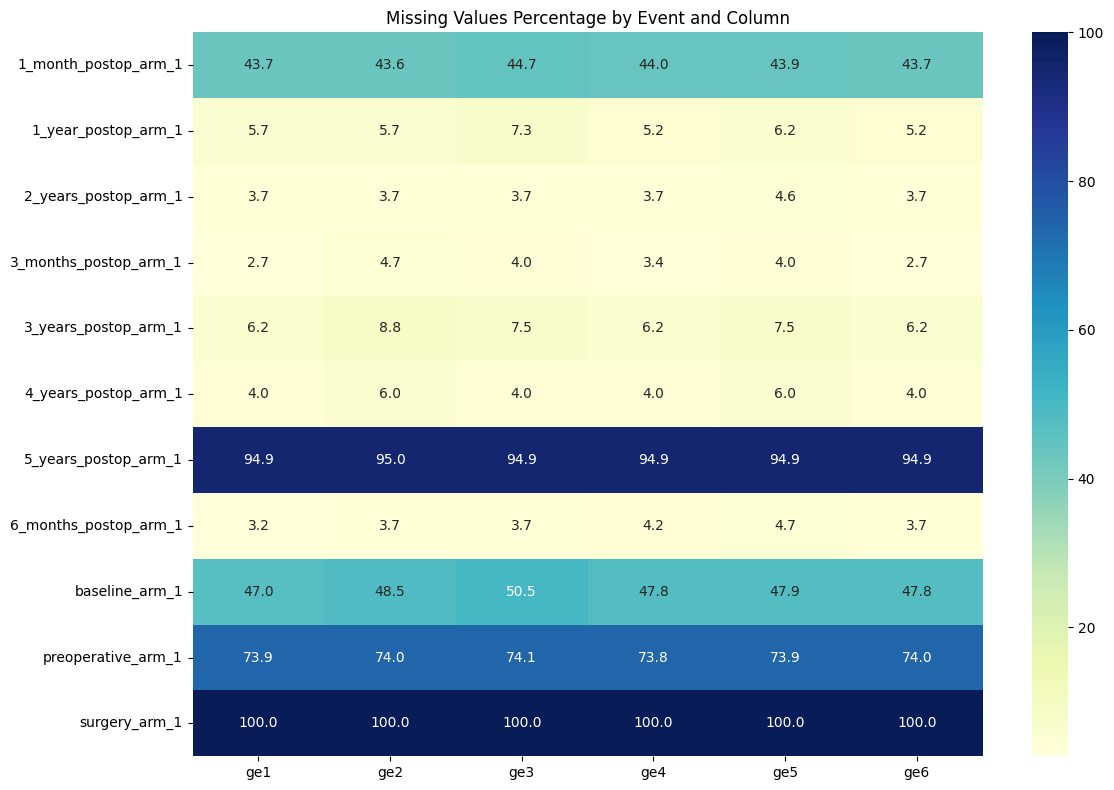

In [4]:
# First, let's create a function to calculate missing value percentages
def calculate_missing_percentages(df, columns, group_col):
    # Group by both id and the specified column to handle multiple rows per (id, group_col)
    grouped = df.groupby(['id', group_col])
    
    # Aggregate by taking the first non-null value for each (id, group_col) combination
    aggregated_df = grouped[columns].apply(lambda x: x.bfill().ffill().iloc[0] if len(x) > 0 else pd.Series([None] * len(columns), index=columns))
    aggregated_df = aggregated_df.reset_index()
    
    # Now group by the specified column only
    grouped_by_event = aggregated_df.groupby(group_col)
    
    # Initialize a dictionary to store results
    missing_percentages = {}
    
    # Calculate missing percentages for each group
    for name, group in grouped_by_event:
        # Calculate percentage of missing values for each column
        missing_pct = group[columns].isna().mean() * 100
        missing_percentages[name] = missing_pct
    
    # Convert to DataFrame for better visualization
    result_df = pd.DataFrame(missing_percentages)
    return result_df.T # Transpose for better readability

# Columns of interest
ge_columns = ['ge1', 'ge2', 'ge3', 'ge4', 'ge5', 'ge6']

# Calculate missing percentages for each redcap_event_name
missing_pct_by_event = calculate_missing_percentages(df, ge_columns, 'redcap_event_name')

# Display the results
print(missing_pct_by_event)

plt.figure(figsize=(12, 8))
sns.heatmap(missing_pct_by_event, annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('Missing Values Percentage by Event and Column')
plt.tight_layout()
plt.show()

In [5]:
df['redcap_event_name'].value_counts()

redcap_event_name
surgery_arm_1            4380
baseline_arm_1           4351
preoperative_arm_1       1995
5_years_postop_arm_1     1653
1_month_postop_arm_1     1071
1_year_postop_arm_1       392
6_months_postop_arm_1     377
3_months_postop_arm_1     298
2_years_postop_arm_1      225
3_years_postop_arm_1      165
4_years_postop_arm_1      100
Name: count, dtype: int64

In [6]:
df.columns

Index(['id', 'operation_date', 'redcap_event_name', 'postop_comp',
       'ComplicationDate', 'los', 'readmission_30d', 'DischargeDate', 'dob',
       'qol_date', 'age_diagnosis', 'gender', 'overall_primary_tumour',
       'overall_regional_ln', 'overall_distant_metastasis', 'neotx___notx',
       'neotx___chemo', 'neotx___rads', 'neotx___chemorads', 'neotx___immuno',
       'neotx___other', 'procedure123456', 'expectation_treatment',
       'path_esoph_primtumour', 'path_esoph_regionalln',
       'path_esoph_distantmetast', 'gp1', 'gp2', 'gp3', 'gp4', 'gp5', 'gp6',
       'gp7', 'gs1', 'gs2', 'gs3', 'gs4', 'gs5', 'gs6', 'gs7', 'ge1', 'ge2',
       'ge3', 'ge4', 'ge5', 'ge6', 'gf1', 'gf2', 'gf3', 'gf4', 'gf5', 'gf6',
       'gf7', 'a_hn1', 'a_hn2', 'a_hn3', 'a_hn4', 'a_hn5', 'a_hn7', 'a_hn10',
       'a_e1', 'a_e2', 'a_e3', 'a_e4', 'a_e5', 'a_e6', 'a_e7', 'a_c6', 'a_c2',
       'a_act11'],
      dtype='object')

In [7]:
#drop dates
df = df.drop(columns=["ComplicationDate", "dob", "operation_date", "DischargeDate"]) #qol_date
df.columns

Index(['id', 'redcap_event_name', 'postop_comp', 'los', 'readmission_30d',
       'qol_date', 'age_diagnosis', 'gender', 'overall_primary_tumour',
       'overall_regional_ln', 'overall_distant_metastasis', 'neotx___notx',
       'neotx___chemo', 'neotx___rads', 'neotx___chemorads', 'neotx___immuno',
       'neotx___other', 'procedure123456', 'expectation_treatment',
       'path_esoph_primtumour', 'path_esoph_regionalln',
       'path_esoph_distantmetast', 'gp1', 'gp2', 'gp3', 'gp4', 'gp5', 'gp6',
       'gp7', 'gs1', 'gs2', 'gs3', 'gs4', 'gs5', 'gs6', 'gs7', 'ge1', 'ge2',
       'ge3', 'ge4', 'ge5', 'ge6', 'gf1', 'gf2', 'gf3', 'gf4', 'gf5', 'gf6',
       'gf7', 'a_hn1', 'a_hn2', 'a_hn3', 'a_hn4', 'a_hn5', 'a_hn7', 'a_hn10',
       'a_e1', 'a_e2', 'a_e3', 'a_e4', 'a_e5', 'a_e6', 'a_e7', 'a_c6', 'a_c2',
       'a_act11'],
      dtype='object')

In [8]:
#drop unused columns
df = df.drop(columns=['age_diagnosis', 'gender',
        'overall_primary_tumour', 'overall_regional_ln',
        'overall_distant_metastasis', 'neotx___notx', 'neotx___chemo',
        'neotx___rads', 'neotx___chemorads', 'neotx___immuno', 'neotx___other',
        'procedure123456', 'expectation_treatment', 'path_esoph_primtumour',
        'path_esoph_regionalln', 'path_esoph_distantmetast', 'readmission_30d',
        'postop_comp', 'los']) 
df.columns

Index(['id', 'redcap_event_name', 'qol_date', 'gp1', 'gp2', 'gp3', 'gp4',
       'gp5', 'gp6', 'gp7', 'gs1', 'gs2', 'gs3', 'gs4', 'gs5', 'gs6', 'gs7',
       'ge1', 'ge2', 'ge3', 'ge4', 'ge5', 'ge6', 'gf1', 'gf2', 'gf3', 'gf4',
       'gf5', 'gf6', 'gf7', 'a_hn1', 'a_hn2', 'a_hn3', 'a_hn4', 'a_hn5',
       'a_hn7', 'a_hn10', 'a_e1', 'a_e2', 'a_e3', 'a_e4', 'a_e5', 'a_e6',
       'a_e7', 'a_c6', 'a_c2', 'a_act11'],
      dtype='object')

In [9]:
# Step 2: Preprocess numerical and ordinal columns
# True numerical columns: Ensure float/int dtype
# numerical_cols = ['los', 'age_diagnosis']
# for col in numerical_cols:
#     df[col] = df[col].astype(float)

#Step 3
# Ordinal columns: Treat as numerical (already float)
ordinal_cols = (
    [f"gp{i}" for i in range(1, 8)] + [f"gs{i}" for i in range(1, 8)] +
    [f"ge{i}" for i in range(1, 7)] + [f"gf{i}" for i in range(1, 8)] +
    [f"a_hn{i}" for i in range(1, 6)] + ["a_hn7", "a_hn10"] +
    [f"a_e{i}" for i in range(1, 8)] + ["a_c6", "a_c2", "a_act11"]
)
# Subset for this example
ordinal_cols = [col for col in ordinal_cols if col in df.columns]
for col in ordinal_cols:
    df[col] = df[col].astype(float)

#Step 4
# Categorical-like columns: Treat as categorical
# categorical_like_cols = [
#     'overall_primary_tumour', 'overall_regional_ln', 'overall_distant_metastasis', 
#     'path_esoph_primtumour', 'path_esoph_regionalln', 'path_esoph_distantmetast'
# ]
# for col in categorical_like_cols:
#     df[col] = df[col].astype(str)  # Convert to string to handle mixed types
#     df[col] = df[col].astype('category')
df

,id,redcap_event_name,qol_date,gp1,gp2,gp3,gp4,gp5,gp6,gp7,...,a_e1,a_e2,a_e3,a_e4,a_e5,a_e6,a_e7,a_c6,a_c2,a_act11
0,1,baseline_arm_1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,5_years_postop_arm_1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,baseline_arm_1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,surgery_arm_1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,surgery_arm_1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15002,1788,baseline_arm_1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15003,1788,baseline_arm_1,2025-06-09,2.0,0.0,2.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,2.0,0.0,2.0,2.0,0.0
15004,1788,baseline_arm_1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15005,1789,baseline_arm_1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
columns_to_check = ['gp1', 'gp2', 'gp3', 'gp4', 'gp5', 'gp6', 'gp7', 
                    'gs1', 'gs2', 'gs3', 'gs4', 'gs5', 'gs6', 'gs7', 
                    'ge1', 'ge2', 'ge3', 'ge4', 'ge5', 'ge6', 
                    'gf1', 'gf2', 'gf3', 'gf4', 'gf5', 'gf6', 'gf7', 
                    'a_hn1', 'a_hn2', 'a_hn3', 'a_hn4', 'a_hn5', 'a_hn7', 'a_hn10', 
                    'a_e1', 'a_e2', 'a_e3', 'a_e4', 'a_e5', 'a_e6', 'a_e7', 
                    'a_c6', 'a_c2', 'a_act11']

# Keep only rows with at least one non-missing value
df = df[df[columns_to_check].notna().any(axis=1)]

# Remove duplicates where all 44 FACT-E scores are identical for the same patient
df = df.drop_duplicates(subset=['id'] + columns_to_check, keep='first')

# Count unique patients and patients with multiple rows
unique_patients = df['id'].nunique()
patients_with_multiple = (df['id'].value_counts() > 1).sum()

print(f"Unique patients: {unique_patients}")
print(f"Patients with multiple rows: {patients_with_multiple}")
df

Unique patients: 1216
Patients with multiple rows: 643


,id,redcap_event_name,qol_date,gp1,gp2,gp3,gp4,gp5,gp6,gp7,...,a_e1,a_e2,a_e3,a_e4,a_e5,a_e6,a_e7,a_c6,a_c2,a_act11
15,2,baseline_arm_1,2007-01-12,1.0,0.0,0.0,3.0,0.0,0.0,0.0,...,2.0,0.0,0.0,3.0,0.0,4.0,0.0,4.0,0.0,1.0
23,3,baseline_arm_1,2008-03-18,2.0,0.0,1.0,3.0,3.0,0.0,2.0,...,2.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
33,4,baseline_arm_1,2007-06-08,3.0,3.0,1.0,2.0,3.0,3.0,3.0,...,4.0,4.0,4.0,2.0,1.0,0.0,0.0,0.0,4.0,1.0
50,6,baseline_arm_1,2005-08-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.0,3.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
60,7,baseline_arm_1,2007-03-15,1.0,1.0,0.0,2.0,0.0,1.0,1.0,...,4.0,1.0,1.0,2.0,0.0,0.0,0.0,3.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14992,1784,baseline_arm_1,2025-05-26,3.0,3.0,NaN,0.0,NaN,0.0,0.0,...,4.0,4.0,1.0,0.0,3.0,2.0,0.0,3.0,1.0,0.0
14998,1786,baseline_arm_1,2025-06-02,2.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,4.0,2.0,0.0
15000,1787,baseline_arm_1,2025-06-09,3.0,2.0,2.0,4.0,0.0,4.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15003,1788,baseline_arm_1,2025-06-09,2.0,0.0,2.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,2.0,0.0,2.0,2.0,0.0


In [11]:
df[df['id']==639]

,id,redcap_event_name,qol_date,gp1,gp2,gp3,gp4,gp5,gp6,gp7,...,a_e1,a_e2,a_e3,a_e4,a_e5,a_e6,a_e7,a_c6,a_c2,a_act11
5983,639,baseline_arm_1,2016-05-30,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,3.0,0.0,2.0,3.0,0.0
5984,639,baseline_arm_1,2016-07-06,3.0,0.0,0.0,0.0,NaN,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,3.0,0.0,2.0,2.0,0.0
5986,639,preoperative_arm_1,2016-08-15,2.0,NaN,2.0,NaN,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,3.0,0.0,1.0,2.0,0.0


In [17]:
df['qol_date']

15      2007-01-12
23      2008-03-18
33      2007-06-08
50      2005-08-15
60      2007-03-15
           ...    
14992   2025-05-26
14998   2025-06-02
15000   2025-06-09
15003   2025-06-09
15006   2025-06-16
Name: qol_date, Length: 2736, dtype: datetime64[ns]

In [12]:
df['redcap_event_name'].value_counts()

redcap_event_name
baseline_arm_1           1037
preoperative_arm_1        433
1_month_postop_arm_1      388
1_year_postop_arm_1       197
6_months_postop_arm_1     184
3_months_postop_arm_1     146
2_years_postop_arm_1      117
5_years_postop_arm_1      100
3_years_postop_arm_1       85
4_years_postop_arm_1       49
Name: count, dtype: int64

In [13]:
df['id'].value_counts() > 1

id
557      True
826      True
536      True
307      True
275      True
        ...  
772     False
774     False
775     False
777     False
1789    False
Name: count, Length: 1216, dtype: bool

In [14]:
# Get the value counts for patients with multiple rows
multiple_rows_counts = df['id'].value_counts()
patients_with_multiple_rows = multiple_rows_counts[multiple_rows_counts > 1]

print("Patients with multiple rows and their counts:")
print(patients_with_multiple_rows)

# If you want to see the distribution of how many patients have 2 rows, 3 rows, etc.
print("\nDistribution of row counts:")
print(patients_with_multiple_rows.value_counts().sort_index())

Patients with multiple rows and their counts:
id
557     10
826     10
536     10
307      9
275      9
        ..
300      2
574      2
776      2
1625     2
268      2
Name: count, Length: 643, dtype: int64

Distribution of row counts:
count
2     238
3     173
4     110
5      65
6      23
7      19
8       6
9       6
10      3
Name: count, dtype: int64


In [15]:
# Get the value counts for all patients
patient_counts = df['id'].value_counts()

# Find patients with exactly 3 rows
patients_with_3_rows = patient_counts[patient_counts == 3]
print("Patients with exactly 3 rows:")
print(patients_with_3_rows)

# Find patients with exactly 4 rows
patients_with_4_rows = patient_counts[patient_counts == 4]
print("\nPatients with exactly 4 rows:")
print(patients_with_4_rows)

# If you want to see the patient IDs as a list
print(f"\nPatient IDs with 3 rows: {patients_with_3_rows.index.tolist()}")
print(f"Patient IDs with 4 rows: {patients_with_4_rows.index.tolist()}")

Patients with exactly 3 rows:
id
639     3
636     3
969     3
1088    3
646     3
       ..
1635    3
335     3
285     3
519     3
279     3
Name: count, Length: 173, dtype: int64

Patients with exactly 4 rows:
id
560     4
771     4
740     4
1574    4
531     4
       ..
1336    4
790     4
1213    4
823     4
788     4
Name: count, Length: 110, dtype: int64

Patient IDs with 3 rows: [639, 636, 969, 1088, 646, 1228, 1176, 645, 1236, 1092, 1120, 1136, 554, 638, 952, 1431, 1179, 1070, 1188, 1449, 1022, 602, 1015, 1014, 597, 596, 1043, 1013, 1447, 1008, 1004, 1224, 1003, 617, 583, 619, 1049, 627, 1219, 1067, 1021, 1071, 613, 783, 1421, 744, 1381, 829, 1380, 724, 1376, 730, 1373, 819, 734, 735, 736, 818, 743, 806, 1331, 717, 754, 803, 800, 758, 760, 799, 764, 798, 1362, 770, 791, 1360, 1358, 778, 1383, 832, 937, 1277, 934, 652, 928, 926, 654, 924, 1413, 785, 907, 664, 1412, 1270, 896, 1410, 1281, 1387, 1406, 1405, 689, 1287, 867, 859, 694, 695, 1292, 1296, 847, 702, 840, 1309, 780, 642

In [16]:
# Define target variables
target_vars = ([f"gp{i}" for i in range(1, 8)] + [f"gs{i}" for i in range(1, 8)] +
                [f"ge{i}" for i in range(1, 7)] + [f"gf{i}" for i in range(1, 8)] +
                [f"a_hn{i}" for i in range(1, 6)] + ["a_hn7", "a_hn10"] +
                [f"a_e{i}" for i in range(1, 8)] + ["a_c6", "a_c2", "a_act11"])

# Calculate patient-level missingness
patient_level = df.groupby('id')[target_vars].apply(lambda x: x.notna().any()).mean()
patient_missingness = (1 - patient_level) * 100

print(f"Patient-level missingness range: {patient_missingness.min():.1f}% - {patient_missingness.max():.1f}%")

Patient-level missingness range: 0.8% - 32.8%


# Classification process + metrics 

In [17]:
# Add these imports at the top of your file
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_score, recall_score

def process_for_classification(values, min_val=0, max_val=4):
    """
    Process imputed values for classification evaluation
    
    Parameters:
    -----------
    values : array-like
        Raw imputed values
    min_val : int
        Minimum allowed value (default: 0)
    max_val : int  
        Maximum allowed value (default: 4)
        
    Returns:
    --------
    numpy.ndarray
        Processed values as integers in range [min_val, max_val]
    """
    # Round to nearest integer
    rounded = np.round(values)
    # Clip to valid range
    clipped = np.clip(rounded, min_val, max_val)
    return clipped.astype(int)

In [18]:
def calculate_classification_metrics(y_true, y_pred, classes=None):
    """
    Calculate classification metrics for multi-class problem
    
    Parameters:
    -----------
    y_true : array-like
        True class labels
    y_pred : array-like
        Predicted class labels
    classes : array-like, optional
        Class labels (default: [0, 1, 2, 3, 4])
        
    Returns:
    --------
    dict
        Dictionary containing classification metrics
    """
    if classes is None:
        classes = np.array([0, 1, 2, 3, 4])
    
    try:
        # Convert to numpy arrays
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        
        # Basic accuracy
        accuracy = accuracy_score(y_true, y_pred)
        
        # Macro-averaged metrics (average across classes)
        precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
        recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
        
        # Weighted-averaged metrics (weighted by class frequency)
        precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
        
        # For multi-class AUC, we need to binarize the labels
        try:
            # Only calculate AUC if we have more than one class present
            if len(np.unique(y_true)) > 1:
                y_true_bin = label_binarize(y_true, classes=classes)
                y_pred_bin = label_binarize(y_pred, classes=classes)
                
                # If only 2 classes present, reshape
                if y_true_bin.shape[1] == 1:
                    auc_score = roc_auc_score(y_true_bin, y_pred_bin)
                else:
                    # Multi-class AUC (macro average)
                    auc_score = roc_auc_score(y_true_bin, y_pred_bin, average='macro', multi_class='ovr')
            else:
                auc_score = np.nan
        except:
            auc_score = np.nan
        
        # Per-class metrics
        cm = confusion_matrix(y_true, y_pred, labels=classes)
        
        # Calculate sensitivity (recall) and specificity for each class
        per_class_metrics = {}
        for i, class_label in enumerate(classes):
            if i < cm.shape[0] and i < cm.shape[1]:
                tp = cm[i, i] if i < cm.shape[0] and i < cm.shape[1] else 0
                fp = cm[:, i].sum() - tp if i < cm.shape[1] else 0
                fn = cm[i, :].sum() - tp if i < cm.shape[0] else 0
                tn = cm.sum() - tp - fp - fn
                
                # Sensitivity (recall/true positive rate)
                sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
                
                # Specificity (true negative rate)
                specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
                
                # PPV (precision)
                ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
                
                # NPV
                npv = tn / (tn + fn) if (tn + fn) > 0 else 0
                
                per_class_metrics[f'class_{class_label}'] = {
                    'sensitivity': sensitivity,
                    'specificity': specificity,
                    'ppv': ppv,
                    'npv': npv
                }
        
        # Average across classes for summary
        avg_sensitivity = np.mean([metrics['sensitivity'] for metrics in per_class_metrics.values()])
        avg_specificity = np.mean([metrics['specificity'] for metrics in per_class_metrics.values()])
        avg_ppv = np.mean([metrics['ppv'] for metrics in per_class_metrics.values()])
        avg_npv = np.mean([metrics['npv'] for metrics in per_class_metrics.values()])
        
        return {
            'accuracy': accuracy,
            'auc_multiclass': auc_score,
            'precision_macro': precision_macro,
            'recall_macro': recall_macro,
            'precision_weighted': precision_weighted,
            'recall_weighted': recall_weighted,
            'avg_sensitivity': avg_sensitivity,
            'avg_specificity': avg_specificity,
            'avg_ppv': avg_ppv,
            'avg_npv': avg_npv,
            'per_class_metrics': per_class_metrics,
            'confusion_matrix': cm
        }
        
    except Exception as e:
        print(f"Error calculating classification metrics: {e}")
        return {
            'accuracy': np.nan,
            'auc_multiclass': np.nan,
            'precision_macro': np.nan,
            'recall_macro': np.nan,
            'precision_weighted': np.nan,
            'recall_weighted': np.nan,
            'avg_sensitivity': np.nan,
            'avg_specificity': np.nan,
            'avg_ppv': np.nan,
            'avg_npv': np.nan,
            'per_class_metrics': {},
            'confusion_matrix': None
        }

# Model - MICE

In [ ]:
def apply_mice_imputation(df, columns_to_impute, validation_df=None, validation_masks=None, original_values=None):
    """
    Apply MICE imputation using miceforest package
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Data with missing values
    columns_to_impute : list
        List of column names to impute
    validation_df : pandas.DataFrame, optional
        Validation dataset with artificially missing values
    validation_masks : dict, optional
        Dictionary of masks for validation data
    original_values : dict, optional
        Dictionary of original values for validation
        
    Returns:
    --------
    imputed_df : pandas.DataFrame
        Data with imputed values
    validation_results : dict, optional
        Validation results if validation data provided
    """

    # Set threads for LightGBM
    os.environ['OMP_NUM_THREADS'] = '10'
    
    # Drop non-numeric columns that miceforest cannot handle
    df_mice = df.select_dtypes(exclude=['object', 'datetime64[ns]', 'datetime64']).copy()

    kernel = mf.ImputationKernel(
        df_mice,
        datasets=1,
        variable_schema={
            col: [c for c in df_mice.columns if c != col] for col in columns_to_impute
        },
        random_state=42
    )

    # Run imputation
    for _ in tqdm(range(5), desc="MICE Imputation"):
        kernel.mice(
            iterations=1,
            verbose=False,
            num_boost_round=80,
            max_depth=10,
            num_threads=10
        )
    
    imputed_mice = kernel.complete_data(0)
    # Put results back into a copy of the original df (which still has redcap_event_name etc.)
    imputed_df = df.copy()
    for col in columns_to_impute:
        if col in imputed_mice.columns:
            imputed_df[col] = imputed_mice[col].values
    
    # Check if there's a label encoder for redcap_event_name that needs inverse transformation
    # if 'redcap_event_name' in imputed_df.columns:
    #     try:
    #         # This is optional - only execute if le_redcap exists in the global scope
    #         if 'le_redcap' in globals():
    #             # Check if we're dealing with numeric values (could be int or float)
    #             if pd.api.types.is_numeric_dtype(imputed_df['redcap_event_name']) or \
    #                (hasattr(imputed_df['redcap_event_name'], 'cat') and pd.api.types.is_numeric_dtype(imputed_df['redcap_event_name'].cat.categories)):
    #                 imputed_df['redcap_event_name'] = globals()['le_redcap'].inverse_transform(imputed_df['redcap_event_name'].astype(int))
    #     except Exception as e:
    #         print(f"Warning: Could not inverse transform redcap_event_name: {e}")
    
    # Validate if validation data provided
    validation_results = None
    if validation_df is not None and validation_masks is not None and original_values is not None:
        validation_results = {}
        
        # Compare imputed values to real values
        for col in columns_to_impute:
            # Get indices where values were artificially set to NaN
            mask = validation_masks[col] & validation_df[col].isna()
            
            if mask.sum() == 0:
                validation_results[col] = {
                    'error': "No artificially missing values"
                }
                continue
                
            real_vals = original_values[col][mask]
            imputed_vals = imputed_df[col][mask]
            
            # Calculate continuous metrics (MAE and RMSE) - NO ROUNDING
            mae = mean_absolute_error(real_vals, imputed_vals)
            rmse = np.sqrt(mean_squared_error(real_vals, imputed_vals))
            
            # Calculate classification metrics - WITH ROUNDING
            real_vals_class = process_for_classification(real_vals)
            imputed_vals_class = process_for_classification(imputed_vals)
            
            classification_metrics = calculate_classification_metrics(real_vals_class, imputed_vals_class)
            
            validation_results[col] = {
                'mae': mae,
                'rmse': rmse,
                'accuracy': classification_metrics['accuracy'],
                'auc_multiclass': classification_metrics['auc_multiclass'],
                'avg_sensitivity': classification_metrics['avg_sensitivity'],
                'avg_specificity': classification_metrics['avg_specificity'],
                'avg_ppv': classification_metrics['avg_ppv'],
                'avg_npv': classification_metrics['avg_npv'],
                'precision_macro': classification_metrics['precision_macro'],
                'recall_macro': classification_metrics['recall_macro'],
                'real_distribution': real_vals.describe(),
                'imputed_distribution': imputed_vals.describe()
            }
    
    return imputed_df, validation_results

In [28]:
ordinal_cols = (
    [f"gp{i}" for i in range(1, 8)] + [f"gs{i}" for i in range(1, 8)] +
    [f"ge{i}" for i in range(1, 7)] + [f"gf{i}" for i in range(1, 8)] +
    [f"a_hn{i}" for i in range(1, 6)] + ["a_hn7", "a_hn10"] +
    [f"a_e{i}" for i in range(1, 8)] + ["a_c6", "a_c2", "a_act11"]
)
columns_to_impute = ordinal_cols#['ge1', 'ge2', 'ge3', 'ge4', 'ge5', 'ge6']
imputed_df_mice, validation_results_mice = apply_mice_imputation(df, columns_to_impute)


MICE Imputation:   0%|          | 0/5 [00:00<?, ?it/s]

DTypePromotionError: The DType <class 'numpy.dtypes.DateTime64DType'> could not be promoted by <class 'numpy.dtypes.Float64DType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.DateTime64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Int8DType'>, <class 'numpy.dtypes.Int8DType'>, <class 'numpy.dtypes.Int8DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <

# Model - Bayesian PCA 

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
import torch.distributions as dist
import time


class BayesianPCATorch(nn.Module):
    """
    PyTorch implementation of Bayesian PCA model
    """
    def __init__(self, n_features, n_components):
        super(BayesianPCATorch, self).__init__()
        self.n_features = n_features
        self.n_components = n_components
        
        # Priors for loadings (W)
        self.w_mu = nn.Parameter(torch.zeros(n_features, n_components), requires_grad=True)
        self.w_log_sigma = nn.Parameter(torch.zeros(n_features, n_components), requires_grad=True)
        
        # Noise precision (inverse variance)
        self.log_tau = nn.Parameter(torch.zeros(1), requires_grad=True)
        
    def forward(self, z):
        # Sample from approximate posterior for W
        w_sigma = torch.exp(self.w_log_sigma)
        epsilon_w = torch.randn_like(self.w_mu)
        w = self.w_mu + w_sigma * epsilon_w
        
        # Compute reconstruction
        tau = torch.exp(self.log_tau)
        reconstruction = torch.matmul(z, w.t())
        
        return reconstruction, w, tau
    
    def sample_loadings(self, n_samples=1):
        """Sample loadings (W) from the approximate posterior"""
        w_sigma = torch.exp(self.w_log_sigma)
        epsilon_w = torch.randn(n_samples, self.n_features, self.n_components, device=self.w_mu.device)
        w_samples = self.w_mu.unsqueeze(0) + w_sigma.unsqueeze(0) * epsilon_w
        return w_samples


class BayesianPCAImputer(BaseEstimator, TransformerMixin):
    """
    A scikit-learn compatible Bayesian PCA imputation model
    using PyTorch for GPU acceleration
    """
    
    def __init__(self,
                 n_components=5,
                 n_samples=1000,
                 batch_size=64,
                 n_epochs=100,
                 learning_rate=0.01,
                 device=None,
                 verbose=True):
        """
        Initialize PyTorch-based Bayesian PCA imputer
        
        Parameters:
        -----------
        n_components : int
            Number of principal components
        n_samples : int
            Number of posterior samples to draw
        batch_size : int
            Batch size for training
        n_epochs : int
            Number of training epochs
        learning_rate : float
            Learning rate for optimizer
        device : str or torch.device
            Device to use ('cuda' or 'cpu'), defaults to CUDA if available
        verbose : bool
            Whether to print progress
        """
        self.n_components = n_components
        self.n_samples = n_samples
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.learning_rate = learning_rate
        
        # Set device
        if device is None:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)
            
        self.verbose = verbose
        
        # Initialize model components
        self.pca_model = None  # For standard PCA initialization
        self.scaler = None     # For data scaling
        self.model = None      # The PyTorch model
        
    def fit(self, X, y=None):
        """
        Fit Bayesian PCA model using PyTorch
        
        Parameters:
        -----------
        X : pandas.DataFrame
            Data with missing values
            
        Returns:
        --------
        self : object
            Returns self
        """
        # Store column names and index
        self.columns = X.columns
        self.index = X.index
        
        # Create a copy of data
        X_data = X.copy()
        
        # Convert to numpy array
        X_array = X_data.values
        
        # Initialize scaler
        self.scaler = StandardScaler()
        
        # Simple imputation for initial values (for fitting the scaler)
        simple_imputer = SimpleImputer(strategy='mean')
        X_imputed_for_scaling = simple_imputer.fit_transform(X_array)
        
        # Scale data
        X_scaled = self.scaler.fit_transform(X_imputed_for_scaling)
        
        # Create a mask for missing values
        self.missing_mask = np.isnan(X_array)
        
        # Perform standard PCA for initialization
        pca = PCA(n_components=self.n_components)
        pca.fit(X_scaled)
        self.pca_model = pca
        
        # Initialize PyTorch model
        n_samples, n_features = X_scaled.shape
        self.model = BayesianPCATorch(n_features, self.n_components).to(self.device)
        
        # Initialize model parameters using standard PCA
        with torch.no_grad():
            # Initialize W to PCA loadings
            self.model.w_mu.data = torch.tensor(pca.components_.T, dtype=torch.float32).to(self.device)
            
            # Initialize noise precision (tau) based on explained variance
            explained_var = pca.explained_variance_
            noise_var = np.mean(np.var(X_scaled, axis=0) - np.sum(explained_var))
            noise_var = max(noise_var, 1e-6)  # Ensure positive variance
            self.model.log_tau.data = torch.tensor([np.log(1.0 / noise_var)], dtype=torch.float32).to(self.device)
        
        # Prepare data for PyTorch training
        # Fill missing values with zeros (will be handled by the mask)
        X_for_torch = X_scaled.copy()
        X_for_torch[self.missing_mask] = 0.0
        
        # Convert to PyTorch tensors
        X_tensor = torch.tensor(X_for_torch, dtype=torch.float32).to(self.device)
        mask_tensor = torch.tensor(~self.missing_mask, dtype=torch.float32).to(self.device)
        
        # Initialize latent variables (z) using PCA scores
        z_init = pca.transform(X_scaled)
        
        # Store the latent variables as a model parameter
        self.latent_z = nn.Parameter(torch.tensor(z_init, dtype=torch.float32, device=self.device))
        
        # Train the model
        self._train_model(X_tensor, mask_tensor)
        
        # Store final latent variables for later use
        self.z = self.latent_z.detach().cpu().numpy()
        
        return self
    
    def _train_model(self, X, mask):
        """
        Train the Bayesian PCA model using stochastic variational inference
        
        Parameters:
        -----------
        X : torch.Tensor
            Data tensor
        mask : torch.Tensor
            Mask tensor (1 for observed, 0 for missing)
        """
        # Setup optimizer - include latent_z as a parameter of self
        parameters = list(self.model.parameters()) + [self.latent_z]
        optimizer = optim.Adam(parameters, lr=self.learning_rate)
        
        # Setup scheduler for learning rate decay
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5, verbose=self.verbose
        )
        
        # Training loop
        if self.verbose:
            print(f"Training Bayesian PCA model on {self.device}...")
            print(f"Data shape: {X.shape}, Components: {self.n_components}")
            print(f"Missing values: {torch.sum(mask == 0).item()} out of {X.numel()}")
            
        epoch_pbar = range(self.n_epochs)
        if self.verbose:
            epoch_pbar = tqdm(epoch_pbar, desc="Training")
            
        # For early stopping
        best_loss = float('inf')
        patience = 60  # Increased patience to 60
        patience_counter = 0
        
        # Store z for later use
        for epoch in epoch_pbar:
            optimizer.zero_grad()
            
            # Forward pass
            x_recon, w_samples, tau = self.model(self.latent_z)
            
            # Compute loss - only for observed values
            # Likelihood term (reconstruction error)
            mse_loss = torch.sum(mask * (X - x_recon) ** 2)
            
            # Prior on z (standard normal)
            z_prior_loss = 0.5 * torch.sum(self.latent_z ** 2)
            
            # Prior on W (standard normal)
            w_mu = self.model.w_mu
            w_sigma = torch.exp(self.model.w_log_sigma)
            w_prior_loss = 0.5 * torch.sum(w_mu ** 2 + w_sigma ** 2 - torch.log(w_sigma ** 2) - 1)
            
            # Total loss
            loss = mse_loss * tau + z_prior_loss + w_prior_loss
            
            # Backward pass and optimization step
            loss.backward()
            optimizer.step()
            
            # Get current loss
            current_loss = loss.item()
            
            # Update learning rate
            scheduler.step(current_loss)
            
            # Update progress bar with current loss
            if self.verbose:
                epoch_pbar.set_postfix({"Loss": f"{current_loss:.4f}"})
            
            # Early stopping
            if current_loss < best_loss:
                best_loss = current_loss
                patience_counter = 0
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                if self.verbose:
                    print(f"Early stopping at epoch {epoch + 1}")
                break
                
    def transform(self, X):
        """
        Impute missing values using Bayesian PCA
        
        Parameters:
        -----------
        X : pandas.DataFrame
            Data with missing values
            
        Returns:
        --------
        imputed_df : pandas.DataFrame
            Data with imputed values
        """
        # Create copy to avoid modifying original
        imputed_df = X.copy()
        
        # Check if this is the same data used for fitting
        new_data = not np.array_equal(X.index, self.index) or not np.array_equal(X.columns, self.columns)
        
        if new_data:
            # For new data, we need to project onto the learned components
            # This is a simplified approach and could be improved
            
            # Create a copy of data
            X_data = X.copy()
            
            # Convert to numpy array
            X_array = X_data.values
            
            # Simple imputation for initial values
            simple_imputer = SimpleImputer(strategy='mean')
            X_imputed = simple_imputer.fit_transform(X_array)
            
            # Scale data
            X_scaled = self.scaler.transform(X_imputed)
            
            # Create a mask for missing values
            missing_mask = np.isnan(X_array)
            
            # Project data onto principal components
            z = self.pca_model.transform(X_scaled)
            
            # Get mean of W from model
            w_samples = self.model.sample_loadings(n_samples=self.n_samples)
            w_mean = w_samples.mean(dim=0).cpu().detach().numpy()
            
            # Reconstruct data
            X_reconstructed = np.dot(z, w_mean.T)
            
            # Inverse transform to original scale
            X_reconstructed = self.scaler.inverse_transform(X_reconstructed)
            
            # Only replace missing values
            X_array_imputed = X_array.copy()
            X_array_imputed[missing_mask] = X_reconstructed[missing_mask]
            
            # Convert back to DataFrame
            imputed_df = pd.DataFrame(X_array_imputed, 
                                      columns=X.columns, 
                                      index=X.index)
        else:
            # For the same data used in fitting, use posterior samples
            
            # Sample from the model multiple times to get uncertainty estimates
            w_samples = self.model.sample_loadings(n_samples=self.n_samples)  # [n_samples, n_features, n_components]
            w_mean = w_samples.mean(dim=0).cpu().detach().numpy()  # [n_features, n_components]
            
            # Reconstruct data from latent variables (z)
            X_reconstructed = np.dot(self.z, w_mean.T)  # [n_samples, n_features]
            
            # Inverse transform to original scale
            X_reconstructed = self.scaler.inverse_transform(X_reconstructed)
            
            # Convert to DataFrame
            X_reconstructed_df = pd.DataFrame(X_reconstructed, 
                                             columns=self.columns, 
                                             index=self.index)
            
            # Only replace missing values
            for col in imputed_df.columns:
                missing_idx = imputed_df[col].isna()
                if missing_idx.any():
                    imputed_df.loc[missing_idx, col] = X_reconstructed_df.loc[missing_idx, col].values
        
        return imputed_df
    
    def fit_transform(self, X, y=None):
        """
        Fit and transform
        
        Parameters:
        -----------
        X : pandas.DataFrame
            Data with missing values
            
        Returns:
        --------
        imputed_df : pandas.DataFrame
            Data with imputed values
        """
        self.fit(X)
        return self.transform(X)


def apply_bpca_imputation(df, columns_to_impute, validation_df=None, validation_masks=None, original_values=None, display_progress=True, use_gpu=True):
    """
    Apply Bayesian PCA imputation to patient data using PyTorch
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Patient data with missing values
    columns_to_impute : list
        List of column names to impute
    validation_df : pandas.DataFrame, optional
        Validation dataset with artificially missing values
    validation_masks : dict, optional
        Dictionary of masks for validation data
    original_values : dict, optional
        Dictionary of original values for validation
    display_progress : bool
        Whether to display progress
    use_gpu : bool
        Whether to use GPU acceleration
        
    Returns:
    --------
    imputed_df : pandas.DataFrame
        Data with imputed values
    validation_results : dict, optional
        Validation results if validation data provided
    """
    # Extract relevant columns including potential predictors
    # Use all columns except those with excessive missing values
    threshold = 0.5  # Columns with more than 50% missing values are excluded
    # columns_to_use = [col for col in df.columns 
    #                     if df[col].isna().mean() < threshold]
    columns_to_use = [col for col in df.columns
                        if df[col].isna().mean() < threshold
                        and pd.api.types.is_numeric_dtype(df[col])]
    
    # Ensure all columns_to_impute are included
    for col in columns_to_impute:
        if col not in columns_to_use:
            columns_to_use.append(col)
    
    # Extract subset of data
    X = df[columns_to_use].copy()
    
    # Ensure all columns are numeric
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    
    # Initialize Bayesian PCA imputer
    n_components = min(5, len(columns_to_use) - 1)  # Ensure n_components is valid
    
    # Set device based on user preference and availability
    device = 'cuda' if use_gpu and torch.cuda.is_available() else 'cpu'
    
    # Determine batch size based on data size
    batch_size = min(64, len(X))  # Default 64, but smaller if dataset is tiny
    
    # Configure epochs based on data size
    n_epochs = max(100, min(300, 10000 // len(X) + 30))  # Updated minimum to 100 epochs
    
    if display_progress:
        print(f"Starting PyTorch Bayesian PCA imputation with {n_components} components")
        print(f"Using device: {device}")
        print(f"Training for up to {n_epochs} epochs with batch size {batch_size}")
        
        if device == 'cuda':
            print(f"GPU Info: {torch.cuda.get_device_name(0)}")
            print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
        
    # Determine reasonable number of posterior samples based on data size
    n_samples = 1000  # Default
    
    imputer = BayesianPCAImputer(
        n_components=n_components,
        n_samples=n_samples,
        batch_size=batch_size,
        n_epochs=n_epochs,
        learning_rate=0.01,
        device=device,
        verbose=display_progress
    )
    
    # Fit and transform with progress tracking
    start_time = None
    if display_progress:
        start_time = time.time()
        print("Training PyTorch Bayesian PCA imputation model...")
    
    X_imputed = imputer.fit_transform(X)
    
    if display_progress and start_time:
        elapsed = time.time() - start_time
        print(f"BPCA imputation completed in {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")
    
    # Create imputed dataframe
    imputed_df = df.copy()
    imputed_df[columns_to_impute] = X_imputed[columns_to_impute]
    
    # Validate if validation data provided
    validation_results = None
    if validation_df is not None and validation_masks is not None and original_values is not None:
        validation_results = {}
        validation_start_time = None
        
        if display_progress:
            validation_start_time = time.time()
            print("\nStarting validation on test data...")
        
        # Extract validation data
        X_val = validation_df[columns_to_use].copy()
        
        # Ensure all validation columns are numeric
        for col in X_val.columns:
            X_val[col] = pd.to_numeric(X_val[col], errors='coerce')
            
        # Impute validation data
        X_val_imputed = imputer.transform(X_val)
        
        # For storing overall metrics
        all_real_vals = []
        all_imputed_vals = []
        column_metrics = []
        
        # Compare imputed values to real values
        with tqdm(columns_to_impute, desc="Validating results") as pbar:
            for col in pbar:
                pbar.set_description(f"Validating {col}")
                # Get indices where values were artificially set to NaN
                mask = validation_masks[col] & validation_df[col].isna()
                
                if mask.sum() == 0:
                    validation_results[col] = {
                        'error': "No artificially missing values"
                    }
                    continue
                    
                real_vals = original_values[col][mask]
                imputed_vals = X_val_imputed[col][mask]
                
                # Collect all values for overall metrics
                all_real_vals.extend(real_vals.values)
                all_imputed_vals.extend(imputed_vals.values)
                
                # Calculate continuous metrics (MAE and RMSE) - NO ROUNDING
                mae = mean_absolute_error(real_vals, imputed_vals)
                rmse = np.sqrt(mean_squared_error(real_vals, imputed_vals))
                
                # Calculate classification metrics - WITH ROUNDING
                real_vals_class = process_for_classification(real_vals)
                imputed_vals_class = process_for_classification(imputed_vals)
                
                classification_metrics = calculate_classification_metrics(real_vals_class, imputed_vals_class)
                
                # Store metrics for summary
                column_metrics.append({
                    'column': col,
                    'mae': mae,
                    'rmse': rmse,
                    'accuracy': classification_metrics['accuracy'],
                    'count': len(real_vals)
                })
                
                validation_results[col] = {
                    'mae': mae,
                    'rmse': rmse,
                    'accuracy': classification_metrics['accuracy'],
                    'auc_multiclass': classification_metrics['auc_multiclass'],
                    'avg_sensitivity': classification_metrics['avg_sensitivity'],
                    'avg_specificity': classification_metrics['avg_specificity'],
                    'avg_ppv': classification_metrics['avg_ppv'],
                    'avg_npv': classification_metrics['avg_npv'],
                    'precision_macro': classification_metrics['precision_macro'],
                    'recall_macro': classification_metrics['recall_macro'],
                    'real_distribution': real_vals.describe(),
                    'imputed_distribution': imputed_vals.describe()
                }
                
                # Update progress
                pbar.set_postfix({"MAE": f"{mae:.4f}", "RMSE": f"{rmse:.4f}", "Acc": f"{classification_metrics['accuracy']:.4f}"})
        
        # Calculate overall metrics
        if all_real_vals:
            overall_mae = mean_absolute_error(all_real_vals, all_imputed_vals)
            overall_rmse = np.sqrt(mean_squared_error(all_real_vals, all_imputed_vals))
            
            validation_results['overall'] = {
                'mae': overall_mae,
                'rmse': overall_rmse,
                'total_values': len(all_real_vals)
            }
        
        # Print detailed summary
        if display_progress:
            validation_time = time.time() - validation_start_time if validation_start_time else 0
            total_time = validation_time + (time.time() - start_time if start_time else 0)
            
            print("\n" + "="*80)
            print(f"PYTORCH BAYESIAN PCA IMPUTATION SUMMARY (Device: {device})")
            print("="*80)
            
            # Time information
            print(f"\nTIMING INFORMATION:")
            print(f"  Training Time: {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")
            print(f"  Validation Time: {validation_time:.2f} seconds ({validation_time/60:.2f} minutes)")
            print(f"  Total Time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")
            
            # Overall metrics
            if 'overall' in validation_results:
                print(f"\nOVERALL METRICS (across {validation_results['overall']['total_values']} values):")
                print(f"  MAE: {validation_results['overall']['mae']:.4f}")
                print(f"  RMSE: {validation_results['overall']['rmse']:.4f}")
            
            # Per-column metrics
            print("\nPER-COLUMN METRICS:")
            print("-"*80)
            print(f"{'Column':<20} {'MAE':<10} {'RMSE':<10} {'Accuracy':<10} {'Count':<10}")
            print("-"*80)
            
            for metric in sorted(column_metrics, key=lambda x: x['mae']):
                print(f"{metric['column']:<20} {metric['mae']:<10.4f} {metric['rmse']:<10.4f} {metric['accuracy']:<10.4f} {metric['count']:<10}")
            
            print("="*80)
    
    return imputed_df, validation_results

In [ ]:
# Define columns to impute
ordinal_cols = (
    [f"gp{i}" for i in range(1, 8)] + [f"gs{i}" for i in range(1, 8)] +
    [f"ge{i}" for i in range(1, 7)] + [f"gf{i}" for i in range(1, 8)] +
    [f"a_hn{i}" for i in range(1, 6)] + ["a_hn7", "a_hn10"] +
    [f"a_e{i}" for i in range(1, 8)] + ["a_c6", "a_c2", "a_act11"]
)
columns_to_impute = ordinal_cols#['ge1', 'ge2', 'ge3', 'ge4', 'ge5', 'ge6']

# Apply Transformer imputation
imputed_df_bpca, validation_results_bpca = apply_bpca_imputation(df, columns_to_impute)

Starting PyTorch Bayesian PCA imputation with 5 components
Using device: cpu
Training for up to 100 epochs with batch size 64
Training PyTorch Bayesian PCA imputation model...


Training Bayesian PCA model on cpu...
Data shape: torch.Size([5230, 10]), Components: 5
Missing values: 36725 out of 52300


Training:   3%|▎         | 3/100 [00:04<02:25,  1.50s/it, Loss=143057371136.0000]


KeyboardInterrupt: 

In [96]:
imputed_df_bpca['ge1']

0        1.286870
14       1.268549
18       1.276519
22       1.286916
25       1.000000
           ...   
18178    1.341442
18179    1.000000
18180    1.354321
18181    1.354068
18185    1.341488
Name: ge1, Length: 5230, dtype: float64

# Model - Da Xu (interview paper) DL method

In [ ]:
class DeepAutoencoderModel(nn.Module):
    """
    Deep Autoencoder model for missing value imputation with patient embedding
    
    Based on the papers:
    - "A Deep Learning–Based Unsupervised Method to Impute Missing Values in Patient Records"
    - "A deep learning–based, unsupervised method to impute missing values in electronic health records"
    """
    def __init__(self, input_dim, patient_vocab_size, embedding_dim=16, hidden_dims=(64, 32, 16, 32, 64), 
                 dropout_rate=0.2, activation='relu'):
        """
        Initialize the model
        
        Parameters:
        -----------
        input_dim : int
            Dimension of input data
        patient_vocab_size : int
            Number of unique patients for embedding
        embedding_dim : int
            Size of patient embedding vectors
        hidden_dims : tuple
            Sizes of hidden layers
        dropout_rate : float
            Dropout rate for regularization
        activation : str
            Activation function ('relu' or 'elu')
        """
        super(DeepAutoencoderModel, self).__init__()
        
        # Patient embedding layer
        self.patient_embedding = nn.Embedding(patient_vocab_size + 1, embedding_dim)
        
        # Build encoder layers
        self.encoder_layers = nn.ModuleList()
        prev_dim = input_dim
        
        # Get the number of layers for encoder (half of hidden_dims rounded up)
        encoder_size = (len(hidden_dims) + 1) // 2
        
        for i in range(encoder_size):
            layer = nn.Sequential(
                nn.Linear(prev_dim, hidden_dims[i]),
                nn.BatchNorm1d(hidden_dims[i]),
                nn.ReLU() if activation == 'relu' else nn.ELU(),
                nn.Dropout(dropout_rate)
            )
            self.encoder_layers.append(layer)
            prev_dim = hidden_dims[i]
        
        # Code layer dimension (bottleneck)
        self.code_dim = hidden_dims[encoder_size - 1]
        
        # Build decoder layers
        self.decoder_layers = nn.ModuleList()
        
        # First decoder layer takes concatenated code and patient embedding
        prev_dim = self.code_dim + embedding_dim
        
        for i in range(encoder_size, len(hidden_dims)):
            layer = nn.Sequential(
                nn.Linear(prev_dim, hidden_dims[i]),
                nn.BatchNorm1d(hidden_dims[i]),
                nn.ReLU() if activation == 'relu' else nn.ELU(),
                nn.Dropout(dropout_rate)
            )
            self.decoder_layers.append(layer)
            prev_dim = hidden_dims[i]
        
        # Output layer
        self.output_layer = nn.Linear(prev_dim, input_dim)
        
    def encode(self, x):
        """
        Encode input data to latent representation
        
        Parameters:
        -----------
        x : torch.Tensor
            Input data
            
        Returns:
        --------
        torch.Tensor
            Encoded representation
        """
        h = x
        for layer in self.encoder_layers:
            h = layer(h)
        return h
    
    def decode(self, code, patient_emb):
        """
        Decode latent representation to reconstructed input
        
        Parameters:
        -----------
        code : torch.Tensor
            Encoded representation
        patient_emb : torch.Tensor
            Patient embedding vectors
            
        Returns:
        --------
        torch.Tensor
            Reconstructed input
        """
        # Concatenate code and patient embedding
        h = torch.cat([code, patient_emb], dim=1)
        
        for layer in self.decoder_layers:
            h = layer(h)
            
        return self.output_layer(h)
    
    def forward(self, x, patient_ids):
        """
        Forward pass through the model
        
        Parameters:
        -----------
        x : torch.Tensor
            Input data
        patient_ids : torch.Tensor
            Patient IDs
            
        Returns:
        --------
        torch.Tensor
            Reconstructed input
        """
        # Get patient embeddings
        patient_emb = self.patient_embedding(patient_ids).squeeze(1)
        
        # Encode input
        code = self.encode(x)
        
        # Decode latent representation
        output = self.decode(code, patient_emb)
        
        return output


class MaskedMSELoss(nn.Module):
    """
    MSE loss that ignores missing values
    """
    def __init__(self):
        super(MaskedMSELoss, self).__init__()
        
    def forward(self, pred, target, mask):
        """
        Calculate MSE loss only on observed values
        
        Parameters:
        -----------
        pred : torch.Tensor
            Predicted values
        target : torch.Tensor
            Target values
        mask : torch.Tensor
            Binary mask (1 for observed, 0 for missing)
            
        Returns:
        --------
        torch.Tensor
            Masked MSE loss
        """
        # Apply mask to predictions and targets
        masked_pred = pred * mask
        masked_target = target * mask
        
        # Calculate squared error
        squared_error = (masked_pred - masked_target) ** 2
        
        # Sum squared error and count observed values
        sum_squared_error = torch.sum(squared_error)
        count = torch.sum(mask) + 1e-8  # Add small epsilon to avoid division by zero
        
        # Return MSE
        return sum_squared_error / count

class TemporalSimilarityLoss(nn.Module):
    """
    Loss component for temporal similarity regularization
    """
    def __init__(self):
        super(TemporalSimilarityLoss, self).__init__()
        
    def forward(self, pred, patient_batch_indices, timestamps):
        """
        Calculate temporal similarity loss based on actual time differences within patients
        
        Parameters:
        -----------
        pred : torch.Tensor
            Predicted values
        patient_batch_indices : torch.Tensor
            Indices grouping patients in the batch
        timestamps : torch.Tensor
            Actual timestamps (as days since epoch)
            
        Returns:
        --------
        torch.Tensor
            Temporal similarity loss
        """
        batch_size = pred.size(0)
        
        # If batch size is too small, return zero loss
        if batch_size <= 1:
            return torch.tensor(0.0, device=pred.device)
        
        # Expand dimensions for pairwise operations
        pred_expanded_1 = pred.unsqueeze(1)  # [batch, 1, features]
        pred_expanded_2 = pred.unsqueeze(0)  # [1, batch, features]
        
        timestamps_1 = timestamps.unsqueeze(1)  # [batch, 1]
        timestamps_2 = timestamps.unsqueeze(0)  # [1, batch]
        
        # Calculate pairwise differences between predictions
        pred_diff = torch.sum((pred_expanded_1 - pred_expanded_2) ** 2, dim=2)
        
        # Create patient similarity mask (1 where same patient, 0 otherwise)
        patient_expanded_1 = patient_batch_indices.unsqueeze(1)
        patient_expanded_2 = patient_batch_indices.unsqueeze(0)
        patient_mask = (patient_expanded_1 == patient_expanded_2).float()
        
        # Create diagonal mask to exclude self-comparisons
        diag_mask = 1.0 - torch.eye(batch_size, device=pred.device)
        
        # Combine masks
        combined_mask = patient_mask * diag_mask
        
        # If no patient pairs exist, return zero loss
        if torch.sum(combined_mask) == 0:
            return torch.tensor(0.0, device=pred.device)
        
        # Calculate temporal similarity weights based on actual time differences
        temporal_diff = torch.abs(timestamps_1 - timestamps_2)
        similarity_weights = 1.0 / (temporal_diff + 1.0)
        
        # Apply masks and weights
        weighted_diff = pred_diff * similarity_weights * combined_mask
        
        # Normalize and return loss
        return torch.sum(weighted_diff) / (torch.sum(combined_mask) + 1e-8)


class DeepAutoencoderImputer:
    """
    Deep Learning-Based Unsupervised Method for Missing Value Imputation
    
    Based on the papers:
    - "A Deep Learning–Based Unsupervised Method to Impute Missing Values in Patient Records"
    - "A deep learning–based, unsupervised method to impute missing values in electronic health records"
    """
    
    def __init__(self, 
                 embedding_dim=16,
                 hidden_layers=(64, 32, 16, 32, 64),
                 activation='relu',
                 dropout_rate=0.2,
                 learning_rate=0.001,
                 weight_decay=0.00001,
                 temporal_weight=0.3,
                 batch_size=16,
                 epochs=100,
                 patience=10,
                 device=None,
                 verbose=1):
        """
        Initialize imputer
        
        Parameters:
        -----------
        embedding_dim : int
            Size of patient embedding vectors
        hidden_layers : tuple
            Sizes of hidden layers
        activation : str
            Activation function ('relu' or 'elu')
        dropout_rate : float
            Dropout rate for regularization
        learning_rate : float
            Learning rate for optimizer
        weight_decay : float
            L2 regularization strength
        temporal_weight : float
            Weight for temporal similarity regularization
        batch_size : int
            Batch size for training
        epochs : int
            Maximum number of training epochs
        patience : int
            Patience for early stopping
        device : str or torch.device
            Device to use ('cpu', 'cuda', or None for auto-detection)
        verbose : int
            Verbosity level (0 or 1)
        """
        self.embedding_dim = embedding_dim
        self.hidden_layers = hidden_layers
        self.activation = activation
        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.temporal_weight = temporal_weight
        self.batch_size = batch_size
        self.epochs = epochs
        self.patience = patience
        self.verbose = verbose
        
        # Set device
        if device is None:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)
            
        if self.verbose:
            print(f"Using device: {self.device}")
            
            # Print CUDA details if using GPU
            if self.device.type == 'cuda':
                print(f"CUDA device: {torch.cuda.get_device_name(0)}")
                print(f"CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
                print(f"CUDA capability: {torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}")
        
        # Will be initialized during fitting
        self.model = None
        self.scaler = None
        self.columns = None
        self.patient_id_col = None
        self.time_col = None
        self.numerical_cols = []
        self.categorical_cols = []
        self.ordinal_cols = []
        self.cat_encoders = {}
        self.columns_to_impute = None
        self.history = {'train_loss': [], 'val_loss': []}
        
    def fit(self, X, patient_id_col, time_col=None, numerical_cols=None, 
            categorical_cols=None, ordinal_cols=None):
        """
        Fit the imputer model
        
        Parameters:
        -----------
        X : DataFrame
            Input data with missing values
        patient_id_col : str
            Name of the column containing patient IDs
        time_col : str, optional
            Name of the column containing time information
        numerical_cols : list, optional
            Names of numerical columns. If None, autodetect.
        categorical_cols : list, optional
            Names of categorical columns. If None, autodetect.
        ordinal_cols : list, optional
            Names of ordinal columns. If None, autodetect.
            
        Returns:
        --------
        self : object
            Returns self
        """
        self.original_data = X.copy()
        self.original_columns = X.columns.tolist()
        self.patient_id_col = patient_id_col
        self.time_col = time_col
        
        # Autodetect column types if not provided
        if numerical_cols is None:
            numerical_cols = X.select_dtypes(include=['float', 'int']).columns.tolist()
            # Exclude patient_id_col
            if patient_id_col in numerical_cols:
                numerical_cols.remove(patient_id_col)
        self.numerical_cols = numerical_cols
        
        if categorical_cols is None:
            categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
            # Exclude patient_id_col and time_col
            if patient_id_col in categorical_cols:
                categorical_cols.remove(patient_id_col)
            if time_col and time_col in categorical_cols:
                categorical_cols.remove(time_col)
        self.categorical_cols = categorical_cols
        
        if ordinal_cols is None:
            ordinal_cols = []
        self.ordinal_cols = ordinal_cols
        
        # Preprocess data
        X_processed, missing_mask, cat_indices = self._preprocess_data(X, fit=True)
        
        # Extract patient IDs
        patient_ids = X[patient_id_col].values
        
        # Train model
        self._train_model(X_processed, patient_ids, missing_mask)
        
        return self
    
    def _preprocess_data(self, X, fit=True):
        """
        Preprocess data for the imputation model
        
        Parameters:
        -----------
        X : DataFrame
            Input data
        fit : bool
            Whether to fit or transform
            
        Returns:
        --------
        tuple
            (processed data, missing mask, categorical indices)
        """
        # Make a copy of the input data
        X_processed = X.copy()

        # Track the derived date columns to avoid adding them to columns_to_impute
        self.derived_date_cols = []

        # Handle datetime column if present
        if self.time_col and self.time_col in X.columns and pd.api.types.is_datetime64_any_dtype(X[self.time_col]):
            # Extract features from datetime
            date_year_col = f'{self.time_col}_year'
            date_month_col = f'{self.time_col}_month'
            date_day_col = f'{self.time_col}_day'
            
            X_processed[date_year_col] = X[self.time_col].dt.year
            X_processed[date_month_col] = X[self.time_col].dt.month
            X_processed[date_day_col] = X[self.time_col].dt.day
            
            # Store derived date columns
            self.derived_date_cols = [date_year_col, date_month_col, date_day_col]
            
            # Add these new columns to numerical cols but NOT to columns_to_impute
            if fit:
                for col in self.derived_date_cols:
                    if col not in self.numerical_cols:
                        self.numerical_cols.append(col)
                    
            # Drop the original datetime column
            X_processed = X_processed.drop(columns=[self.time_col])
            
        # Handle redcap_event_name if present (convert to ordinal visit index)
        event_col = 'redcap_event_name'
        if event_col in X.columns:
            VISIT_ORDER = {
                'baseline_arm_1': 0, 'preoperative_arm_1': 1, 'surgery_arm_1': 2,
                '1_month_postop_arm_1': 3, '3_months_postop_arm_1': 4,
                '6_months_postop_arm_1': 5, '1_year_postop_arm_1': 6,
                '2_years_postop_arm_1': 7, '3_years_postop_arm_1': 8,
                '4_years_postop_arm_1': 9, '5_years_postop_arm_1': 10,
            }
            event_index_col = 'redcap_event_index'
            #X_processed[event_index_col] = X[event_col].map(VISIT_ORDER).fillna(-1).astype(int)
            # Use 5 (middle of range) instead of -1 or 99 for unknown visits
            X_processed[event_index_col] = X[event_col].map(VISIT_ORDER).fillna(5).astype(int)
            
            if fit:
                if event_index_col not in self.numerical_cols:
                    self.numerical_cols.append(event_index_col)
                self.derived_date_cols.append(event_index_col)
            
            # Drop original event name column (it's a string)
            X_processed = X_processed.drop(columns=[event_col])

        # Create missing value mask (1 for observed, 0 for missing)
        missing_mask = ~X_processed.isna()

        # Scale numerical columns
        if self.numerical_cols:
            # Use only available numeric columns
            numeric_cols_present = [col for col in self.numerical_cols if col in X_processed.columns]
            
            if fit:
                self.num_scaler = StandardScaler()
                if numeric_cols_present:
                    # Temporarily fill missing values for scaling
                    temp_imputer = SimpleImputer(strategy='mean')
                    X_temp = pd.DataFrame(
                        temp_imputer.fit_transform(X_processed[numeric_cols_present]),
                        columns=numeric_cols_present,
                        index=X_processed.index
                    )
                    
                    # Fit scaler on non-missing data
                    X_numerical_scaled = self.num_scaler.fit_transform(X_temp)
                    
                    # Update processed data with scaled values
                    for i, col in enumerate(numeric_cols_present):
                        X_processed[col] = X_numerical_scaled[:, i]
            else:
                if numeric_cols_present:
                    # Temporarily fill missing values for scaling
                    temp_imputer = SimpleImputer(strategy='mean')
                    X_temp = pd.DataFrame(
                        temp_imputer.fit_transform(X_processed[numeric_cols_present]),
                        columns=numeric_cols_present,
                        index=X_processed.index
                    )
                    
                    # Transform with scaler
                    X_numerical_scaled = self.num_scaler.transform(X_temp)
                    
                    # Update processed data with scaled values
                    for i, col in enumerate(numeric_cols_present):
                        X_processed[col] = X_numerical_scaled[:, i]

        # Encode categorical columns
        cat_indices = {}
        current_idx = len(self.numerical_cols)

        for col in self.categorical_cols:
            if col in X_processed.columns:
                # Handle categorical data safely
                if pd.api.types.is_categorical_dtype(X_processed[col]):
                    # Convert to string first to avoid category errors
                    filled_col = X_processed[col].astype(str).fillna('MISSING')
                else:
                    # Fill NaN values with a placeholder
                    filled_col = X_processed[col].fillna('MISSING')
                
                if fit:
                    # Handle both older and newer scikit-learn versions
                    try:
                        # For newer scikit-learn versions
                        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
                    except TypeError:
                        # For older scikit-learn versions
                        encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
                        
                    encoded = encoder.fit_transform(filled_col.values.reshape(-1, 1))
                    self.cat_encoders[col] = encoder
                else:
                    encoder = self.cat_encoders[col]
                    encoded = encoder.transform(filled_col.values.reshape(-1, 1))
                
                # Add encoded columns
                encoded_cols = [f"{col}_{cat}" for cat in encoder.categories_[0]]
                cat_indices[col] = (current_idx, current_idx + len(encoded_cols))
                current_idx += len(encoded_cols)
                
                for i, encoded_col in enumerate(encoded_cols):
                    X_processed[encoded_col] = encoded[:, i]
                
                # Drop original categorical column
                X_processed = X_processed.drop(columns=[col])
                
                # Update missing mask for one-hot encoded columns
                for encoded_col in encoded_cols:
                    missing_mask[encoded_col] = missing_mask[col]

        # Drop non-numeric columns and ensure all data is numeric
        X_processed = X_processed.select_dtypes(include=[np.number])
        missing_mask = missing_mask[X_processed.columns]

        if fit:
            self.processed_columns = X_processed.columns.tolist()
            
        return X_processed, missing_mask, cat_indices

    def _train_model(self, X_processed, patient_ids, missing_mask):
        """
        Train the imputation model
        
        Parameters:
        -----------
        X_processed : DataFrame
            Preprocessed data
        patient_ids : ndarray
            Patient IDs for each record
        missing_mask : DataFrame
            Binary mask for observed values
        
        Returns:
        --------
        None
        """
        # Convert to numpy arrays
        X_np = X_processed.values
        mask_np = missing_mask.values
        
        # Create patient ID mapping
        unique_patient_ids = np.unique(patient_ids)
        patient_id_to_idx = {id_: i for i, id_ in enumerate(unique_patient_ids)}
        
        # Convert patient IDs to numeric indices (with fallback for unseen patients)
        patient_indices = np.array([patient_id_to_idx.get(id_, len(patient_id_to_idx)) for id_ in patient_ids])
        
        # Also create a mapping from record index to patient index for temporal loss
        record_to_patient_idx = patient_indices.copy()
        
        # Sort by patient ID and time if time column exists
        if self.time_col and self.time_col in self.original_data.columns:
            # Create a DataFrame to sort
            timestamps = pd.to_datetime(self.original_data[self.time_col]).values
            sort_df = pd.DataFrame({
                'patient_idx': patient_indices,
                'time': timestamps
            })
            # Sort by patient, then by time
            sort_indices = sort_df.sort_values(['patient_idx', 'time']).index.values
            
            # Reorder all arrays according to sorted indices
            X_np = X_np[sort_indices]
            mask_np = mask_np[sort_indices]
            patient_indices = patient_indices[sort_indices]
            record_to_patient_idx = record_to_patient_idx[sort_indices]
            timestamps = timestamps[sort_indices]
            
            # Convert timestamps to days since epoch
            timestamps_numeric = timestamps.astype('int64') // (24 * 60 * 60 * 10**9)
        else:
            timestamps_numeric = np.arange(len(X_np))  # Fallback to indices
        
        # Convert to PyTorch tensors
        X_tensor = torch.FloatTensor(X_np)
        mask_tensor = torch.FloatTensor(mask_np)
        patient_tensor = torch.LongTensor(patient_indices)
        patient_batch_tensor = torch.LongTensor(record_to_patient_idx)
        timestamps_tensor = torch.FloatTensor(timestamps_numeric)
        
        # Create dataset and dataloader
        dataset = TensorDataset(X_tensor, mask_tensor, patient_tensor, patient_batch_tensor, timestamps_tensor)
        
        # Split into train and validation sets
        train_size = int(0.8 * len(dataset))
        val_size = len(dataset) - train_size
        train_dataset, val_dataset = torch.utils.data.random_split(
            dataset, [train_size, val_size]
        )
        
        train_loader = DataLoader(
            train_dataset, 
            batch_size=self.batch_size, 
            shuffle=False,  # Keep temporal order
            num_workers=0 if self.device.type == 'cuda' else 2
        )
        
        val_loader = DataLoader(
            val_dataset, 
            batch_size=self.batch_size, 
            shuffle=False,
            num_workers=0 if self.device.type == 'cuda' else 2
        )
        
        # Initialize model
        input_dim = X_np.shape[1]
        patient_vocab_size = len(unique_patient_ids)
        
        if self.verbose:
            print(f"Building model with input dimension {input_dim} and {patient_vocab_size} unique patients")
            
        self.model = DeepAutoencoderModel(
            input_dim=input_dim,
            patient_vocab_size=patient_vocab_size,
            embedding_dim=self.embedding_dim,
            hidden_dims=self.hidden_layers,
            dropout_rate=self.dropout_rate,
            activation=self.activation
        ).to(self.device)
        
        # Initialize loss functions
        masked_loss_fn = MaskedMSELoss().to(self.device)
        temporal_loss_fn = TemporalSimilarityLoss().to(self.device)
        
        # Initialize optimizer
        optimizer = optim.Adam(
            self.model.parameters(), 
            lr=self.learning_rate, 
            weight_decay=self.weight_decay
        )
        
        # Initialize learning rate scheduler
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, 
            mode='min', 
            factor=0.5, 
            patience=self.patience // 2, 
            verbose=self.verbose
        )
        
        # Initialize early stopping variables
        best_val_loss = float('inf')
        best_model_state = None
        patience_counter = 0
        
        # Training loop
        if self.verbose:
            print(f"Starting training for {self.epochs} epochs")
            
        # Use tqdm for progress tracking
        pbar = tqdm(range(self.epochs), desc="Training", disable=not self.verbose)
        
        for epoch in pbar:
            # Training phase
            self.model.train()
            train_loss = 0.0
            train_recon_loss = 0.0
            train_temporal_loss = 0.0
            batch_count = 0
            
            for X_batch, mask_batch, patient_batch, patient_idx_batch, timestamps_batch in train_loader:
                # Move tensors to device
                X_batch = X_batch.to(self.device)
                mask_batch = mask_batch.to(self.device)
                patient_batch = patient_batch.to(self.device)
                patient_idx_batch = patient_idx_batch.to(self.device)
                timestamps_batch = timestamps_batch.to(self.device)
                
                # Forward pass
                output = self.model(X_batch, patient_batch)
                
                # Calculate loss
                recon_loss = masked_loss_fn(output, X_batch, mask_batch)
                
                if self.temporal_weight > 0:
                    temporal_loss = temporal_loss_fn(output, patient_idx_batch, timestamps_batch)
                    loss = recon_loss + self.temporal_weight * temporal_loss
                    
                    # DEBUG: Print temporal loss
                    if batch_count == 0:  # Only first batch per epoch
                        print(f"Epoch {epoch}: recon={recon_loss.item():.4f}, temporal={temporal_loss.item():.4f}")
                else:
                    temporal_loss = torch.tensor(0.0, device=self.device)
                    loss = recon_loss
                
                # Backward pass and optimize
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                # Accumulate losses
                train_loss += loss.item()
                train_recon_loss += recon_loss.item()
                train_temporal_loss += temporal_loss.item()
                batch_count += 1
            
            # Calculate average training losses
            avg_train_loss = train_loss / batch_count
            avg_train_recon_loss = train_recon_loss / batch_count
            avg_train_temporal_loss = train_temporal_loss / batch_count
            
            # Validation phase
            self.model.eval()
            val_loss = 0.0
            val_batch_count = 0
            
            with torch.no_grad():
                for X_batch, mask_batch, patient_batch, patient_idx_batch, timestamps_batch in val_loader:
                    # Move tensors to device
                    X_batch = X_batch.to(self.device)
                    mask_batch = mask_batch.to(self.device)
                    patient_batch = patient_batch.to(self.device)
                    patient_idx_batch = patient_idx_batch.to(self.device)
                    timestamps_batch = timestamps_batch.to(self.device)
                    
                    # Forward pass
                    output = self.model(X_batch, patient_batch)
                    
                    # Calculate loss
                    recon_loss = masked_loss_fn(output, X_batch, mask_batch)
                    
                    if self.temporal_weight > 0:
                        temporal_loss = temporal_loss_fn(output, patient_idx_batch, timestamps_batch)
                        loss = recon_loss + self.temporal_weight * temporal_loss
                    else:
                        loss = recon_loss
                    
                    # Accumulate loss
                    val_loss += loss.item()
                    val_batch_count += 1
            
            # Calculate average validation loss
            avg_val_loss = val_loss / val_batch_count
            
            # Update learning rate scheduler
            scheduler.step(avg_val_loss)
            
            # Update history
            self.history['train_loss'].append(avg_train_loss)
            self.history['val_loss'].append(avg_val_loss)
            
            # Update progress bar
            if self.verbose:
                pbar.set_postfix({
                    "train_loss": f"{avg_train_loss:.4f}",
                    "val_loss": f"{avg_val_loss:.4f}",
                    "recon": f"{avg_train_recon_loss:.4f}",
                    "temporal": f"{avg_train_temporal_loss:.4f}"
                })
            
            # Check for early stopping
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                best_model_state = self.model.state_dict()
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= self.patience:
                    if self.verbose:
                        print(f"Early stopping at epoch {epoch+1}")
                    break
        
        # Load best model
        if best_model_state is not None:
            self.model.load_state_dict(best_model_state)
            
        # Return model to evaluation mode
        self.model.eval()

    def transform(self, X):
        """
        Impute missing values using trained model
        
        Parameters:
        -----------
        X : DataFrame
            Input data with missing values
            
        Returns:
        --------
        DataFrame
            Data with imputed values
        """
        # Check if model is trained
        if self.model is None:
            raise ValueError("Model not trained. Call fit() first.")
        
        # Make a copy of the input data
        X_imputed = X.copy()
        
        # Preprocess data
        X_processed, missing_mask, cat_indices = self._preprocess_data(X, fit=False)
        
        # Get patient IDs
        patient_ids = X[self.patient_id_col].values
        
        # Create patient ID mapping
        unique_patient_ids = np.unique(self.original_data[self.patient_id_col])
        patient_id_to_idx = {id_: i for i, id_ in enumerate(unique_patient_ids)}
        
        # Convert patient IDs to numeric indices (with fallback for unseen patients)
        patient_indices = np.array([patient_id_to_idx.get(id_, len(patient_id_to_idx)) for id_ in patient_ids])
        # Convert patient IDs to numeric indices (use index 0 for unseen patients)
        # patient_indices = np.array([patient_id_to_idx.get(id_, 0) 
        #                             for id_ in patient_ids])
        
        # Convert to PyTorch tensors
        X_tensor = torch.FloatTensor(X_processed.values).to(self.device)
        patient_tensor = torch.LongTensor(patient_indices).to(self.device)
        
        # Perform imputation in batches to avoid memory issues
        batch_size = self.batch_size * 2  # Use larger batch size for inference
        n_samples = X_tensor.shape[0]
        imputed_data = np.zeros_like(X_tensor.cpu().numpy())
        
        with torch.no_grad():
            for i in range(0, n_samples, batch_size):
                end_idx = min(i + batch_size, n_samples)
                batch_X = X_tensor[i:end_idx]
                batch_patient = patient_tensor[i:end_idx]
                
                # Get model predictions
                batch_output = self.model(batch_X, batch_patient)
                
                # Store predictions
                imputed_data[i:end_idx] = batch_output.cpu().numpy()
        
        # Convert back to DataFrame
        imputed_df = pd.DataFrame(imputed_data, columns=X_processed.columns, index=X_processed.index)
        
        # # Inverse scale numerical columns to original scale
        # if hasattr(self, 'num_scaler') and self.num_scaler is not None:
        #     num_cols_present = [c for c in self.numerical_cols 
        #                     if c in imputed_df.columns and not c.startswith(f'{self.time_col}_')]
            
        #     if num_cols_present:
        #         # Inverse transform the imputed scaled values
        #         imputed_scaled = imputed_df[num_cols_present].values
        #         imputed_original_scale = self.num_scaler.inverse_transform(imputed_scaled)
        #         imputed_df[num_cols_present] = imputed_original_scale
                
        # Handle numerical columns
        for col in self.numerical_cols:
            if col in X.columns and not col.startswith(f'{self.time_col}_'):
                # Get mask for missing values in original data
                missing_indices = X[col].isna()
                
                if missing_indices.any():
                    # Only update missing values
                    # If column is in columns_to_impute, round to nearest integer
                    if self.columns_to_impute and col in self.columns_to_impute:
                        X_imputed.loc[missing_indices, col] = np.round(
                            imputed_df.loc[missing_indices, col].values
                        )
                    else:
                        X_imputed.loc[missing_indices, col] = imputed_df.loc[missing_indices, col].values
        
        # Handle categorical columns (need to convert one-hot back to original categories)
        for col in self.categorical_cols:
            if col in X.columns:
                missing_indices = X[col].isna()
                
                if missing_indices.any() and col in cat_indices:
                    # Get the one-hot encoded columns for this categorical variable
                    start_idx, end_idx = cat_indices[col]
                    encoded_cols = self.processed_columns[start_idx:end_idx]
                    
                    # Get indices where values are missing
                    missing_idx = missing_indices[missing_indices].index
                    
                    # Extract one-hot encoded values for the missing entries
                    one_hot_values = imputed_df.loc[missing_idx, encoded_cols].values
                    
                    # Get the index of the max value along axis 1
                    max_indices = np.argmax(one_hot_values, axis=1)
                    
                    # Map back to original categories
                    categories = self.cat_encoders[col].categories_[0]
                    imputed_categories = [categories[idx] for idx in max_indices]
                    
                    # Handle categorical data types safely
                    if pd.api.types.is_categorical_dtype(X[col]):
                        # Get the existing categories
                        existing_cats = X[col].cat.categories
                        
                        # Filter out categories that aren't in the existing ones
                        valid_categories = []
                        for cat in imputed_categories:
                            if cat in existing_cats:
                                valid_categories.append(cat)
                            else:
                                # Use the most common category as fallback
                                most_common = X[col].value_counts().index[0]
                                valid_categories.append(most_common)
                        
                        # Update missing values
                        for idx, cat in zip(missing_idx, valid_categories):
                            X_imputed.loc[idx, col] = cat
                    else:
                        # Update missing values in the original DataFrame
                        X_imputed.loc[missing_idx, col] = imputed_categories
        
        return X_imputed
    
    def fit_transform(self, X, patient_id_col, time_col=None, numerical_cols=None, 
                     categorical_cols=None, ordinal_cols=None):
        """
        Fit the model and impute missing values
        
        Parameters:
        -----------
        X : DataFrame
            Input data with missing values
        patient_id_col : str
            Name of the column containing patient IDs
        time_col : str, optional
            Name of the column containing time information
        numerical_cols : list, optional
            Names of numerical columns. If None, autodetect.
        categorical_cols : list, optional
            Names of categorical columns. If None, autodetect.
        ordinal_cols : list, optional
            Names of ordinal columns. If None, autodetect.
            
        Returns:
        --------
        DataFrame
            Data with imputed values
        """
        self.fit(X, patient_id_col, time_col, numerical_cols, categorical_cols, ordinal_cols)
        return self.transform(X)
    
    def plot_loss(self):
        """
        Plot the training and validation loss curves
        
        Returns:
        --------
        matplotlib figure
            Loss curve plot
        """
        if not self.history['train_loss']:
            raise ValueError("Model has not been trained yet. Call fit() first.")
        
        plt.figure(figsize=(10, 6))
        plt.plot(self.history['train_loss'], label='Training Loss')
        plt.plot(self.history['val_loss'], label='Validation Loss')
        plt.title('Deep Autoencoder Imputation Loss')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend()
        plt.grid(True)
        return plt

def apply_deep_autoencoder_imputation(df, columns_to_impute, validation_df=None, validation_masks=None, original_values=None, 
                                     hidden_layers=(64, 32, 16, 32, 64), latent_dim=8, batch_size=16, epochs=100, learning_rate=0.001):
    """
    Apply deep autoencoder imputation to data with an interface matching your VAE implementation
    
        Parameters:
    -----------
    df : pandas.DataFrame
        Data with missing values
    columns_to_impute : list
        List of column names to impute
    validation_df : pandas.DataFrame, optional
        Validation dataset with artificially missing values
    validation_masks : dict, optional
        Dictionary of masks for validation data
    original_values : dict, optional
        Dictionary of original values for validation
    hidden_layers : tuple
        Sizes of hidden layers
    latent_dim : int
        Dimension of the patient embedding (equivalent to latent_dim in VAE)
    batch_size : int
        Batch size for training
    epochs : int
        Number of training epochs
    learning_rate : float
        Learning rate for optimizer
        
    Returns:
    --------
    imputed_df : pandas.DataFrame
        Data with imputed values
    validation_results : dict, optional
        Validation results if validation data provided
    """
    # Print column information
    print(f"Data has {len(df)} rows and {len(df.columns)} columns")
    print(f"Columns to impute: {columns_to_impute}")

    # IMPORTANT: Make a copy of columns_to_impute to avoid modifying the original list
    local_columns_to_impute = [col for col in columns_to_impute if col in df.columns]

    # Remove any date-derived columns that might have been added from a previous run
    date_derived_cols = [col for col in columns_to_impute if col.startswith('qol_date_')]
    if date_derived_cols:
        print(f"Warning: Date-derived columns found in columns_to_impute: {date_derived_cols}")
        print(f"These will not be used for imputation.")
        for col in date_derived_cols:
            if col in local_columns_to_impute:
                local_columns_to_impute.remove(col)

    # Print missingness information
    print("\nMissingness rates in columns to impute:")
    for col in local_columns_to_impute:
        if col in df.columns:
            miss_rate = df[col].isna().mean() * 100
            print(f"{col}: {miss_rate:.2f}%")
        else:
            print(f"{col}: column not found in data")

    # Extract relevant columns including potential predictors
    # Use all columns except those with excessive missing values
    threshold = 0.5  # Columns with more than 50% missing values are excluded
    # columns_to_use = [col for col in df.columns 
    #                 if df[col].isna().mean() < threshold]
    columns_to_use = [col for col in df.columns
                        if df[col].isna().mean() < threshold
                        and pd.api.types.is_numeric_dtype(df[col])]

    # Ensure all columns_to_impute are included
    for col in local_columns_to_impute:
        if col not in columns_to_use and col in df.columns:
            columns_to_use.append(col)
            
    # Always include id and qol_date if available
    id_col = 'id'
    if id_col not in columns_to_use and id_col in df.columns:
        columns_to_use.append(id_col)
        
    time_col = 'qol_date'
    if time_col not in columns_to_use and time_col in df.columns:
        columns_to_use.append(time_col)
    
    # Always include redcap_event_name if available
    event_col = 'redcap_event_name'
    if event_col not in columns_to_use and event_col in df.columns:
        columns_to_use.append(event_col)

    print(f"\nUsing {len(columns_to_use)} columns for imputation model")

    # Extract subset of data
    X = df[columns_to_use].copy()

    # Ensure all columns to impute are numeric
    print("\nConverting columns to numeric...")
    with tqdm(local_columns_to_impute) as pbar:
        for col in pbar:
            pbar.set_description(f"Processing {col}")
            if col in X.columns:
                # Convert to numeric if possible
                X[col] = pd.to_numeric(X[col], errors='coerce')

    # Check CUDA availability
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Initialize deep autoencoder imputer
    print("\nInitializing deep autoencoder imputer...")
    imputer = DeepAutoencoderImputer(
        embedding_dim=latent_dim,
        hidden_layers=hidden_layers,
        activation='elu',
        dropout_rate=0.3,
        learning_rate=learning_rate,
        weight_decay=0.0001,
        temporal_weight=0.4,
        batch_size=batch_size,
        epochs=epochs,
        patience=20,
        device=device,
        verbose=1
    )

    # Store the columns to impute in the imputer object
    imputer.columns_to_impute = local_columns_to_impute

    # Fit and transform
    print("\nTraining deep autoencoder imputation model...")
    X_imputed = imputer.fit_transform(
        X, 
        patient_id_col=id_col,  # Use 'id' as the patient ID column
        time_col="qol_date",  # Use qol_date for temporal information
        numerical_cols=local_columns_to_impute  # Only specify columns to impute as numerical
    )

    # Create imputed dataframe
    print("\nCreating final imputed dataframe...")
    imputed_df = df.copy()

    # Copy imputed values to the output dataframe
    for col in local_columns_to_impute:
        if col in X_imputed.columns and col in imputed_df.columns:
            # Get mask for missing values in the original data
            missing_mask = df[col].isna()
            # Only update missing values
            imputed_df.loc[missing_mask, col] = X_imputed.loc[missing_mask, col]

    # Print post-imputation statistics
    print("\nPost-imputation statistics:")
    for col in local_columns_to_impute:
        if col in imputed_df.columns:
            # Count originally missing values that have been imputed
            missing_before = df[col].isna().sum()
            missing_after = imputed_df[col].isna().sum()
            num_imputed = missing_before - missing_after
            print(f"{col}: {num_imputed} values imputed")

    # Validate if validation data provided
    validation_results = None
    if validation_df is not None and validation_masks is not None and original_values is not None:
        validation_results = {}
        
        print("\nPerforming validation on held-out data...")
        
        # Extract validation data
        X_val = validation_df[columns_to_use].copy()
        
        # Ensure all validation columns are numeric
        for col in X_val.columns:
            if col in local_columns_to_impute:
                X_val[col] = pd.to_numeric(X_val[col], errors='coerce')
            
        # Impute validation data
        print("Imputing validation data...")
        X_val_imputed = imputer.transform(X_val)
        
        # Compare imputed values to real values
        print("Calculating validation metrics...")
        with tqdm(local_columns_to_impute, desc="Validating results") as pbar:
            for col in pbar:
                pbar.set_description(f"Validating {col}")
                # Get indices where values were artificially set to NaN
                if col not in validation_masks:
                    validation_results[col] = {
                        'error': f"Column {col} not found in validation masks"
                    }
                    continue
                    
                mask = validation_masks[col] & validation_df[col].isna()
                
                if mask.sum() == 0:
                    validation_results[col] = {
                        'error': "No artificially missing values"
                    }
                    continue
                
                if col not in original_values:
                    validation_results[col] = {
                        'error': f"Column {col} not found in original values"
                    }
                    continue
                    
                real_vals = original_values[col][mask]
                
                if col not in X_val_imputed.columns:
                    validation_results[col] = {
                        'error': f"Column {col} not found in imputed values"
                    }
                    continue
                    
                imputed_vals = X_val_imputed.loc[mask, col]
                
                # Calculate continuous metrics (MAE and RMSE) - NO ROUNDING
                mae = mean_absolute_error(real_vals, imputed_vals)
                rmse = np.sqrt(mean_squared_error(real_vals, imputed_vals))
                
                # Calculate classification metrics - WITH ROUNDING
                real_vals_class = process_for_classification(real_vals)
                imputed_vals_class = process_for_classification(imputed_vals)
                
                classification_metrics = calculate_classification_metrics(real_vals_class, imputed_vals_class)
                
                validation_results[col] = {
                    'mae': mae,
                    'rmse': rmse,
                    'accuracy': classification_metrics['accuracy'],
                    'auc_multiclass': classification_metrics['auc_multiclass'],
                    'avg_sensitivity': classification_metrics['avg_sensitivity'],
                    'avg_specificity': classification_metrics['avg_specificity'],
                    'avg_ppv': classification_metrics['avg_ppv'],
                    'avg_npv': classification_metrics['avg_npv'],
                    'precision_macro': classification_metrics['precision_macro'],
                    'recall_macro': classification_metrics['recall_macro'],
                    'real_distribution': real_vals.describe(),
                    'imputed_distribution': pd.Series(imputed_vals).describe()
                }
                
                # Update progress
                pbar.set_postfix({"MAE": f"{mae:.4f}", "RMSE": f"{rmse:.4f}", "Acc": f"{classification_metrics['accuracy']:.4f}"})

    print(f"\nTraining loss plot saved to deep_autoencoder_loss.png")
    print("\nImputation complete!")

    return imputed_df, validation_results

In [ ]:
ordinal_cols = (
    [f"gp{i}" for i in range(1, 8)] + [f"gs{i}" for i in range(1, 8)] +
    [f"ge{i}" for i in range(1, 7)] + [f"gf{i}" for i in range(1, 8)] +
    [f"a_hn{i}" for i in range(1, 6)] + ["a_hn7", "a_hn10"] +
    [f"a_e{i}" for i in range(1, 8)] + ["a_c6", "a_c2", "a_act11"]
)
columns_to_impute = ordinal_cols#['ge1', 'ge2', 'ge3', 'ge4', 'ge5', 'ge6']
# Apply deep autoencoder imputation with explicit column specifications
imputed_df, validation_results = apply_deep_autoencoder_imputation(
    df=df, 
    columns_to_impute=columns_to_impute
)

Data has 5230 rows and 62 columns
Columns to impute: ['ge1', 'ge2', 'ge3', 'ge4', 'ge5', 'ge6']

Missingness rates in columns to impute:
ge1: 79.89%
ge2: 80.52%
ge3: 81.24%
ge4: 80.15%
ge5: 80.21%
ge6: 80.11%

Using 11 columns for imputation model

Converting columns to numeric...


Processing ge6: 100%|██████████| 6/6 [00:00<00:00, 2011.50it/s]


Initializing deep autoencoder imputer...


Using device: cpu

Training deep autoencoder imputation model...
Building model with input dimension 34 and 1754 unique patients
Starting training for 100 epochs


Training:   0%|          | 0/100 [00:52<?, ?it/s]


KeyboardInterrupt: 

# Model - Softimpute

In [ ]:
# Add Travis Brady's SoftImpute implementation to your code
def frob(Uold, Dsqold, Vold, U, Dsq, V):
    denom = (Dsqold ** 2).sum()
    utu = Dsq * (U.T.dot(Uold))
    vtv = Dsqold * (Vold.T.dot(V))
    uvprod = utu.dot(vtv).diagonal().sum()
    num = denom + (Dsqold ** 2).sum() - 2*uvprod
    return num / max(denom, 1e-9)


class SoftImpute:
    def __init__(self, J=2, thresh=1e-05, lambda_=0, maxit=100, random_state=None, verbose=False):
        self.J = J
        self.thresh = thresh
        self.lambda_ = lambda_
        self.maxit = maxit
        self.rs = np.random.RandomState(random_state)
        self.verbose = verbose
        self.u = None
        self.d = None
        self.v = None

    def fit(self, X):
        n, m = X.shape
        xnas = np.isnan(X)
        nz = m*n - xnas.sum()
        xfill = X.copy()
        V = np.zeros((m, self.J))
        U = self.rs.normal(0.0, 1.0, (n, self.J))
        U, _, _ = np.linalg.svd(U, full_matrices=False)
        Dsq = np.ones((self.J, 1))
        #xfill[xnas] = 0.0
        col_means = np.nanmean(xfill, axis=0)
        np.copyto(xfill, col_means, where=np.isnan(xfill))
        ratio = 1.0
        iters = 0
        while ratio > self.thresh and iters < self.maxit:
            iters += 1
            U_old = U
            V_old = V
            Dsq_old = Dsq
            B = U.T.dot(xfill)
            if self.lambda_ > 0:
                tmp = (Dsq / (Dsq + self.lambda_))
                B = B * tmp
            Bsvd = np.linalg.svd(B.T, full_matrices=False)
            V = Bsvd[0]
            Dsq = Bsvd[1][:, np.newaxis]
            U = U.dot(Bsvd[2])
            tmp = Dsq * V.T
            xhat = U.dot(tmp)
            xfill[xnas] = xhat[xnas]
            A = xfill.dot(V).T
            Asvd = np.linalg.svd(A.T, full_matrices=False)
            U = Asvd[0]
            Dsq = Asvd[1][:, np.newaxis]
            V = V.dot(Asvd[2])
            tmp = Dsq * V.T
            xhat = U.dot(tmp)
            xfill[xnas] = xhat[xnas]
            ratio = frob(U_old, Dsq_old, V_old, U, Dsq, V)
            if self.verbose:
                print('iter: %4d ratio = %.5f' % (iters, ratio))
        self.u = U[:, :self.J]
        self.d = Dsq[:self.J]
        self.v = V[:, :self.J]
        return self

    def suv(self, vd):
        res = self.u.dot(vd.T)
        return res

    def predict(self, X, copyto=False):
        vd = self.v * np.outer(np.ones(self.v.shape[0]), self.d)
        X_imp = self.suv(vd)
        if copyto:
            np.copyto(X, X_imp, where=np.isnan(X))
        else:
            return X_imp


def apply_softimpute_imputation(df, columns_to_impute, validation_df=None, validation_masks=None, original_values=None,
                               J=None, thresh=1e-05, lambda_=0, maxit=100, random_state=42):
    """
    Apply SoftImpute imputation using Travis Brady's implementation
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Data with missing values
    columns_to_impute : list
        List of column names to impute
    validation_df : pandas.DataFrame, optional
        Validation dataset with artificially missing values
    validation_masks : dict, optional
        Dictionary of masks for validation data
    original_values : dict, optional
        Dictionary of original values for validation
    J : int, optional
        Number of factors/rank. If None, will be estimated
    thresh : float
        Convergence threshold
    lambda_ : float
        Regularization parameter
    maxit : int
        Maximum number of iterations
    random_state : int
        Random seed for reproducibility
        
    Returns:
    --------
    imputed_df : pandas.DataFrame
        Data with imputed values
    validation_results : dict, optional
        Validation results if validation data provided
    """
    try:
        # Extract relevant columns including potential predictors
        # Use all columns except those with excessive missing values
        threshold = 0.5  # Columns with more than 50% missing values are excluded
        # columns_to_use = [col for col in df.columns 
        #                     if df[col].isna().mean() < threshold]
        columns_to_use = [col for col in df.columns
                        if df[col].isna().mean() < threshold
                        and pd.api.types.is_numeric_dtype(df[col])]
        
        # Ensure all columns_to_impute are included
        for col in columns_to_impute:
            if col not in columns_to_use:
                columns_to_use.append(col)
        
        # Extract subset of data
        X = df[columns_to_use].copy()
        
        # Ensure all columns are numeric
        for col in X.columns:
            X[col] = pd.to_numeric(X[col], errors='coerce')
        
        print(f"SoftImpute (Travis Brady): Using {len(columns_to_use)} columns, imputing {len(columns_to_impute)} columns")
        
        # Set J (rank) if not provided
        if J is None:
            J = min(X.shape[0], X.shape[1]) // 4
            J = max(2, J)  # Ensure at least rank 2
        
        print(f"SoftImpute parameters: J={J}, thresh={thresh}, lambda_={lambda_}, maxit={maxit}")
        
        # Scale the data for better numerical stability
        scaler = StandardScaler()
        
        # Initial imputation with column means for scaling
        X_for_scaling = X.copy()
        for col in X_for_scaling.columns:
            X_for_scaling[col] = X_for_scaling[col].fillna(X_for_scaling[col].mean())
        
        # Fit scaler and transform
        X_scaled = pd.DataFrame(
            scaler.fit_transform(X_for_scaling),
            columns=X.columns,
            index=X.index
        )
        
        # Restore NaN values in scaled data
        X_scaled[X.isna()] = np.nan
        
        # Initialize SoftImpute
        imputer = SoftImpute(
            J=J,
            thresh=thresh,
            lambda_=lambda_,
            maxit=maxit,
            random_state=random_state,
            verbose=True
        )
        
        # Fit and predict
        print("Training SoftImpute imputation model...")
        imputer.fit(X_scaled.values)
        X_imputed_scaled = imputer.predict(X_scaled.values)
        
        # Inverse transform to original scale
        X_imputed = pd.DataFrame(
            scaler.inverse_transform(X_imputed_scaled),
            columns=X.columns,
            index=X.index
        )
        
        # Create imputed dataframe - only replace missing values
        imputed_df = df.copy()
        for col in columns_to_impute:
            if col in X_imputed.columns:
                missing_mask = df[col].isna()
                imputed_df.loc[missing_mask, col] = X_imputed.loc[missing_mask, col]
        
        # Validate if validation data provided
        validation_results = None
        if validation_df is not None and validation_masks is not None and original_values is not None:
            validation_results = {}
            
            # Extract validation data
            X_val = validation_df[columns_to_use].copy()
            
            # Ensure all validation columns are numeric
            for col in X_val.columns:
                X_val[col] = pd.to_numeric(X_val[col], errors='coerce')
                
            # Scale validation data
            X_val_for_scaling = X_val.copy()
            for col in X_val_for_scaling.columns:
                X_val_for_scaling[col] = X_val_for_scaling[col].fillna(X_val_for_scaling[col].mean())
            
            X_val_scaled = pd.DataFrame(
                scaler.transform(X_val_for_scaling),
                columns=X_val.columns,
                index=X_val.index
            )
            
            # Restore NaN values
            X_val_scaled[X_val.isna()] = np.nan
            
            # Create a new imputer for validation data
            val_imputer = SoftImpute(
                J=J,
                thresh=thresh,
                lambda_=lambda_,
                maxit=maxit,
                random_state=random_state,
                verbose=False  # Less verbose for validation
            )
            
            # Impute validation data
            print("Imputing validation data...")
            val_imputer.fit(X_val_scaled.values)
            X_val_imputed_scaled = val_imputer.predict(X_val_scaled.values)
            
            # Inverse transform
            X_val_imputed = pd.DataFrame(
                scaler.inverse_transform(X_val_imputed_scaled),
                columns=X_val.columns,
                index=X_val.index
            )
            
            # Compare imputed values to real values
            with tqdm(columns_to_impute, desc="Validating results") as pbar:
                for col in pbar:
                    pbar.set_description(f"Validating {col}")
                    # Get indices where values were artificially set to NaN
                    mask = validation_masks[col] & validation_df[col].isna()
                    
                    if mask.sum() == 0:
                        validation_results[col] = {
                            'error': "No artificially missing values"
                        }
                        continue
                        
                    real_vals = original_values[col][mask]
                    imputed_vals = X_val_imputed.loc[mask, col]
                    
                    # Calculate continuous metrics (MAE and RMSE) - NO ROUNDING
                    mae = mean_absolute_error(real_vals, imputed_vals)
                    rmse = np.sqrt(mean_squared_error(real_vals, imputed_vals))
                    
                    # Calculate classification metrics - WITH ROUNDING
                    real_vals_class = process_for_classification(real_vals)
                    imputed_vals_class = process_for_classification(imputed_vals)
                    
                    classification_metrics = calculate_classification_metrics(real_vals_class, imputed_vals_class)
                    
                    validation_results[col] = {
                        'mae': mae,
                        'rmse': rmse,
                        'accuracy': classification_metrics['accuracy'],
                        'auc_multiclass': classification_metrics['auc_multiclass'],
                        'avg_sensitivity': classification_metrics['avg_sensitivity'],
                        'avg_specificity': classification_metrics['avg_specificity'],
                        'avg_ppv': classification_metrics['avg_ppv'],
                        'avg_npv': classification_metrics['avg_npv'],
                        'precision_macro': classification_metrics['precision_macro'],
                        'recall_macro': classification_metrics['recall_macro'],
                        'real_distribution': real_vals.describe(),
                        'imputed_distribution': pd.Series(imputed_vals).describe()
                    }
                    
                    # Update progress
                    pbar.set_postfix({"MAE": f"{mae:.4f}", "RMSE": f"{rmse:.4f}", "Acc": f"{classification_metrics['accuracy']:.4f}"})
        
        return imputed_df, validation_results
        
    except Exception as e:
        print(f"Error in SoftImpute imputation: {str(e)}")
        import traceback
        traceback.print_exc()
        
        # Fallback to simple mean imputation
        print("Falling back to simple mean imputation")
        result_df = df.copy()
        for col in columns_to_impute:
            if col in result_df.columns:
                result_df[col] = pd.to_numeric(result_df[col], errors='coerce')
                result_df[col] = result_df[col].fillna(result_df[col].mean())
        return result_df, None

In [36]:
ordinal_cols = (
    [f"gp{i}" for i in range(1, 8)] + [f"gs{i}" for i in range(1, 8)] +
    [f"ge{i}" for i in range(1, 7)] + [f"gf{i}" for i in range(1, 8)] +
    [f"a_hn{i}" for i in range(1, 6)] + ["a_hn7", "a_hn10"] +
    [f"a_e{i}" for i in range(1, 8)] + ["a_c6", "a_c2", "a_act11"]
)
columns_to_impute = ordinal_cols#['ge1', 'ge2', 'ge3', 'ge4', 'ge5', 'ge6']
# Apply deep autoencoder imputation with explicit column specifications
imputed_df, validation_results = apply_softimpute_imputation(
    df=df, 
    columns_to_impute=columns_to_impute
)

SoftImpute (Travis Brady): Using 48 columns, imputing 44 columns
SoftImpute parameters: J=12, thresh=1e-05, lambda_=0, maxit=100
Training SoftImpute imputation model...
iter:    1 ratio = 2.00000
iter:    2 ratio = 1.17932
iter:    3 ratio = 1.15715
iter:    4 ratio = 1.03011
iter:    5 ratio = 0.48539
iter:    6 ratio = 0.30640
iter:    7 ratio = 0.22492
iter:    8 ratio = 0.47394
iter:    9 ratio = 0.48334
iter:   10 ratio = 0.35093
iter:   11 ratio = 0.39443
iter:   12 ratio = 0.31349
iter:   13 ratio = 0.27191
iter:   14 ratio = 0.04629
iter:   15 ratio = 0.00582
iter:   16 ratio = 0.02698
iter:   17 ratio = 0.15518
iter:   18 ratio = 0.44253
iter:   19 ratio = 0.31798
iter:   20 ratio = 0.20299
iter:   21 ratio = 0.17513
iter:   22 ratio = 0.12604
iter:   23 ratio = 0.07183
iter:   24 ratio = 0.13206
iter:   25 ratio = 0.06586
iter:   26 ratio = 0.05695
iter:   27 ratio = 0.03083
iter:   28 ratio = 0.08093
iter:   29 ratio = 0.10034
iter:   30 ratio = 0.06728
iter:   31 ratio = 0.

# LSTM

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# --- Helper: build patient sequences from a flat dataframe -------------------

VISIT_ORDER = {
    'baseline_arm_1':       0,
    'preoperative_arm_1':   1,
    'surgery_arm_1':        2,
    '1_month_postop_arm_1': 3,
    '3_months_postop_arm_1':4,
    '6_months_postop_arm_1':5,
    '1_year_postop_arm_1':  6,
    '2_years_postop_arm_1': 7,
    '3_years_postop_arm_1': 8,
    '4_years_postop_arm_1': 9,
    '5_years_postop_arm_1': 10,
}

def _build_patient_sequences(df, columns_to_impute, patient_col='id',
                             date_col='qol_date', event_col='redcap_event_name'):
    """
    Convert flat dataframe into per-patient sorted sequences.
    Ordering uses redcap_event_name visit index if available, else qol_date.
    Visit index is appended as an extra input feature to the LSTM.
    """
    feature_cols = [c for c in columns_to_impute if c in df.columns]

    # Build sort key: prefer redcap_event_name, fall back to qol_date
    if event_col in df.columns:
        sort_key = df[event_col].map(VISIT_ORDER).fillna(99).astype(int)
    else:
        dates = pd.to_datetime(df[date_col], errors='coerce')
        min_date = dates.min()
        sort_key = (dates - min_date).dt.days.fillna(0).astype(int)

    sequences = []
    for pid, group in df.groupby(patient_col):
        idx = group.index.tolist()
        keys = sort_key[idx].values
        order = np.argsort(keys, kind='stable')
        idx_sorted = [idx[i] for i in order]
        visit_indices = keys[order]                        # e.g. [0, 3, 6]

        X = df.loc[idx_sorted, feature_cols].values.astype(float)  # [T, F]
        mask = ~np.isnan(X)

        sequences.append({
            'patient_id':    pid,
            'indices':       idx_sorted,
            'visit_indices': visit_indices,                # used as extra feature
            'X':             X,
            'mask':          mask,
        })
    return sequences, feature_cols


def _pad_sequences(sequences, n_features):
    """
    Pad sequences to the same length for batch processing.

    Returns
    -------
    X_padded  : np.ndarray [N_patients, max_T, n_features]
    mask      : np.ndarray [N_patients, max_T, n_features]  (True = observed)
    lengths   : list[int]  actual length of each patient sequence
    """
    max_T = max(len(s['indices']) for s in sequences)
    N = len(sequences)

    X_padded = np.zeros((N, max_T, n_features), dtype=np.float32)
    mask_padded = np.zeros((N, max_T, n_features), dtype=bool)

    for i, s in enumerate(sequences):
        T = len(s['indices'])
        X_padded[i, :T, :] = np.nan_to_num(s['X'], nan=0.0)
        mask_padded[i, :T, :] = s['mask']

    lengths = [len(s['indices']) for s in sequences]
    return X_padded, mask_padded, lengths


# --- LSTM model --------------------------------------------------------------
    
class LSTMImputer(nn.Module):
    """
    Simple bidirectional LSTM for longitudinal imputation.
    Input:  [batch, seq_len, n_features]  (missing values filled with 0)
    Output: [batch, seq_len, n_features]  (reconstruction for all positions)
    """
    def __init__(self, input_dim, output_dim, hidden_dim=64, n_layers=1, dropout=0.2):  # ← add dropout
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0,  # ← LSTM internal dropout
        )
        self.dropout = nn.Dropout(dropout)  # ← add explicit dropout layer
        self.output_layer = nn.Linear(hidden_dim * 2, output_dim)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out)  # ← apply dropout before output
        return self.output_layer(out)


# --- Wrapper function --------------------------------------------------------

def apply_lstm_imputation(df, columns_to_impute,
                          validation_df=None, validation_masks=None, original_values=None,
                          patient_col='id', date_col='qol_date',
                          hidden_dim=64, n_layers=2, epochs=100,  # ← increase to 2 layers, 100 epochs
                          learning_rate=0.001, batch_size=32, dropout=0.2):  # ← add dropout param
    """
    Apply bidirectional LSTM imputation using longitudinal patient sequences.

    Parameters
    ----------
    df : pd.DataFrame
        Data with missing values. Must contain patient_col and date_col.
    columns_to_impute : list
        FACT-E column names to impute.
    validation_df, validation_masks, original_values : optional
        Standard validation arguments (same interface as other apply_* functions).
    patient_col : str
        Column name for patient ID (default 'id').
    date_col : str
        Column name for visit date (default 'qol_date').
    hidden_dim : int
        LSTM hidden size (default 64 — keeps model small).
    n_layers : int
        Number of LSTM layers (default 1).
    epochs : int
        Training epochs (default 50).
    learning_rate : float
        Adam learning rate (default 0.001).
    batch_size : int
        Patients per batch (default 32).

    Returns
    -------
    imputed_df : pd.DataFrame
    validation_results : dict or None
    """
    print(f"LSTM Imputation: {len(df)} rows, {df[patient_col].nunique()} patients")

    # --- require id and qol_date to be present ---
    for col in [patient_col, date_col]:
        if col not in df.columns:
            print(f"  Warning: '{col}' not found. Falling back to mean imputation.")
            result_df = df.copy()
            for c in columns_to_impute:
                result_df[c] = pd.to_numeric(result_df[c], errors='coerce')
                result_df[c] = result_df[c].fillna(result_df[c].mean())
            return result_df, None

    # --- build sequences and scale -----------------------------------------
    sequences, feature_cols = _build_patient_sequences(
        df, columns_to_impute, patient_col, date_col)
    n_features = len(feature_cols)

    if n_features == 0:
        print("  No valid feature columns found.")
        return df.copy(), None

    # Compute per-feature mean/std from observed values
    all_obs = np.concatenate([s['X'] for s in sequences], axis=0)  # [total_rows, n_features]
    feat_mean = np.nanmean(all_obs, axis=0)
    feat_std  = np.nanstd(all_obs, axis=0) + 1e-8

    # Standardise X inside each sequence (in-place copy)
    sequences_scaled = []
    for s in sequences:
        X_s = (s['X'] - feat_mean) / feat_std
        X_s[~s['mask']] = 0.0          # zero-fill missing before feeding LSTM
        sequences_scaled.append({**s, 'X_scaled': X_s})

    # --- pad and create tensors --------------------------------------------
    X_padded, mask_padded, lengths = _pad_sequences(sequences_scaled, n_features)

    # Use scaled X + normalised visit index as LSTM input
    # visit index normalised to [0,1] over the 11 timepoints
    X_pad_scaled = np.zeros((len(sequences_scaled),
                             X_padded.shape[1],
                             n_features + 1), dtype=np.float32)  # +1 for visit idx
    for i, s in enumerate(sequences_scaled):
        T = len(s['indices'])
        X_pad_scaled[i, :T, :n_features] = s['X_scaled']
        X_pad_scaled[i, :T,  n_features] = s['visit_indices'] / 10.0  # normalise

    X_tensor    = torch.FloatTensor(X_pad_scaled)
    mask_tensor = torch.FloatTensor(mask_padded.astype(np.float32))   # [N, T, n_features] — unchanged, already correct
    # target: standardised observed values (zero where missing — masked out in loss)
    Y_pad_scaled = np.zeros((len(sequences_scaled),
                             X_padded.shape[1],
                             n_features), dtype=np.float32)   # target: features only
    for i, s in enumerate(sequences_scaled):
        T = len(s['indices'])
        Y_pad_scaled[i, :T, :] = s['X_scaled']
    Y_tensor = torch.FloatTensor(Y_pad_scaled)

    # --- device ------------------------------------------------------------
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"  Using device: {device}")

    # --- model, optimiser, loss --------------------------------------------
    model = LSTMImputer(input_dim=n_features + 1, output_dim=n_features,
                        hidden_dim=hidden_dim, n_layers=n_layers, dropout=dropout).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = MaskedMSELoss().to(device)   # already defined in your codebase

    dataset = TensorDataset(X_tensor, Y_tensor, mask_tensor)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # --- training loop -----------------------------------------------------
    model.train()
    for epoch in tqdm(range(epochs), desc="Training LSTM"):
        epoch_loss = 0.0
        for X_b, Y_b, M_b in loader:
            X_b, Y_b, M_b = X_b.to(device), Y_b.to(device), M_b.to(device)
            pred = model(X_b)
            loss = loss_fn(pred, Y_b, M_b)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

    # --- impute: forward pass on full dataset ------------------------------
    model.eval()
    imputed_df = df.copy()

    with torch.no_grad():
        for i, s in enumerate(sequences_scaled):
            T = len(s['indices'])
            x_in = torch.FloatTensor(X_pad_scaled[i:i+1, :T, :]).to(device)
            pred = model(x_in).cpu().numpy()[0]          # [T, n_features]
            # inverse-scale
            pred_orig = pred * feat_std + feat_mean
            # clip to valid ordinal range [0, 4]
            pred_orig = np.clip(pred_orig, 0, 4)

            # only fill positions that were originally missing
            X_orig = s['X']                              # [T, n_features]
            for t, row_idx in enumerate(s['indices']):
                for f_idx, col in enumerate(feature_cols):
                    if np.isnan(X_orig[t, f_idx]):
                        imputed_df.at[row_idx, col] = pred_orig[t, f_idx]

    # --- validation (same pattern as other apply_* functions) --------------
    validation_results = None
    if validation_df is not None and validation_masks is not None and original_values is not None:
        validation_results = {}

        # Run imputation on validation_df using the trained model
        val_sequences, _ = _build_patient_sequences(
            validation_df, columns_to_impute, patient_col, date_col)

        val_sequences_scaled = []
        for s in val_sequences:
            X_s = (s['X'] - feat_mean) / feat_std
            X_s[~s['mask']] = 0.0
            val_sequences_scaled.append({**s, 'X_scaled': X_s})

        X_val_pad_scaled = np.zeros(
            (len(val_sequences_scaled),
             max(len(s['indices']) for s in val_sequences_scaled),
             n_features + 1), dtype=np.float32)
        for i, s in enumerate(val_sequences_scaled):
            T = len(s['indices'])
            X_val_pad_scaled[i, :T, :n_features] = s['X_scaled']
            X_val_pad_scaled[i, :T,  n_features] = s['visit_indices'] / 10.0

        val_imputed_df = validation_df.copy()
        with torch.no_grad():
            for i, s in enumerate(val_sequences_scaled):
                T = len(s['indices'])
                x_in = torch.FloatTensor(X_val_pad_scaled[i:i+1, :T, :]).to(device)
                pred = model(x_in).cpu().numpy()[0]
                pred_orig = np.clip(pred * feat_std + feat_mean, 0, 4)
                X_orig = s['X']
                for t, row_idx in enumerate(s['indices']):
                    for f_idx, col in enumerate(feature_cols):
                        if np.isnan(X_orig[t, f_idx]):
                            val_imputed_df.at[row_idx, col] = pred_orig[t, f_idx]

        for col in columns_to_impute:
            mask = validation_masks[col] & validation_df[col].isna()
            if mask.sum() == 0:
                validation_results[col] = {'error': "No artificially missing values"}
                continue

            real_vals    = original_values[col][mask]
            imputed_vals = val_imputed_df[col][mask]

            mae  = mean_absolute_error(real_vals, imputed_vals)
            rmse = np.sqrt(mean_squared_error(real_vals, imputed_vals))

            real_cls    = process_for_classification(real_vals)
            imputed_cls = process_for_classification(imputed_vals)
            cls_metrics = calculate_classification_metrics(real_cls, imputed_cls)

            validation_results[col] = {
                'mae': mae, 
                'rmse': rmse,
                'accuracy': cls_metrics['accuracy'],
                'auc_multiclass': cls_metrics['auc_multiclass'],
                'avg_sensitivity': cls_metrics['avg_sensitivity'],
                'avg_specificity': cls_metrics['avg_specificity'],
                'avg_ppv': cls_metrics['avg_ppv'],
                'avg_npv': cls_metrics['avg_npv'],
                'precision_macro': cls_metrics['precision_macro'],
                'recall_macro': cls_metrics['recall_macro'],
                'real_distribution': real_vals.describe(),
                'imputed_distribution': imputed_vals.describe(),
            }

    return imputed_df, validation_results

In [23]:
ordinal_cols = (
    [f"gp{i}" for i in range(1, 8)] + [f"gs{i}" for i in range(1, 8)] +
    [f"ge{i}" for i in range(1, 7)] + [f"gf{i}" for i in range(1, 8)] +
    [f"a_hn{i}" for i in range(1, 6)] + ["a_hn7", "a_hn10"] +
    [f"a_e{i}" for i in range(1, 8)] + ["a_c6", "a_c2", "a_act11"]
)
columns_to_impute = ordinal_cols#['ge1', 'ge2', 'ge3', 'ge4', 'ge5', 'ge6']
# Apply deep autoencoder imputation with explicit column specifications
imputed_df, validation_results = apply_lstm_imputation(
    df=df, 
    columns_to_impute=columns_to_impute
)

LSTM Imputation: 2736 rows, 1216 patients


  Using device: cpu


Training LSTM:   0%|          | 0/50 [00:05<?, ?it/s]


RuntimeError: The size of tensor a (45) must match the size of tensor b (44) at non-singleton dimension 2

# Longitudinal MICE

In [ ]:
def apply_mice_longitudinal_imputation(df, columns_to_impute,
                                       validation_df=None, validation_masks=None, original_values=None,
                                       patient_col='id', date_col='qol_date'):
    """
    Time-aware MICE imputation for longitudinal data.

    Enriches the dataframe with per-patient lag features (previous-timepoint
    values) and a days-since-baseline feature before running standard MICE,
    then strips the auxiliary columns from the result.

    Parameters and return values are identical to apply_mice_imputation.
    """
    print(f"Longitudinal MICE: {len(df)} rows, {df[patient_col].nunique()} patients")

    for col in [patient_col, date_col]:
        if col not in df.columns:
            print(f"  Warning: '{col}' not found. Falling back to standard MICE.")
            return apply_mice_imputation(df, columns_to_impute,
                                         validation_df, validation_masks, original_values)

    def _add_temporal_features(frame, fit_reference=None):
        """
        Add lag-1 and days_since_baseline columns.
        fit_reference: if provided, use its min-date for days calculation
                       (ensures train/val use the same baseline).
        """
        out = frame.copy()
        dates = pd.to_datetime(out[date_col], errors='coerce')
        ref_date = fit_reference if fit_reference is not None else dates.min()
        out['_days_since_baseline'] = (dates - ref_date).dt.days.fillna(0).astype(float)

        # Sort by clinical visit order (redcap_event_name) if available,
        # else fall back to days_since_baseline
        if 'redcap_event_name' in out.columns:
            out['_visit_index'] = out['redcap_event_name'].map(VISIT_ORDER).fillna(99)
            out = out.sort_values([patient_col, '_visit_index'])
            out = out.drop(columns=['_visit_index'])
        else:
            out = out.sort_values([patient_col, '_days_since_baseline'])

        lag_cols = []
        for col_name in columns_to_impute:
            # Add lag-1, lag-2, lag-3
            for lag in [1, 2, 3]:
                lag_name = f'_lag{lag}_{col_name}'
                out[lag_name] = out.groupby(patient_col)[col_name].shift(lag)
                lag_cols.append(lag_name)

        return out, lag_cols, ref_date

    # Build augmented training frame
    df_aug, lag_cols, ref_date = _add_temporal_features(df)

    # Columns to pass into MICE (original + temporal auxiliaries)
    aux_cols = ['_days_since_baseline'] + lag_cols
    # Only keep aux cols that aren't >50% missing
    aux_cols_valid = [c for c in aux_cols if df_aug[c].isna().mean() < 0.5]

    # Build the full column set for MICE
    # (all non-date, non-id numeric columns already in df, plus aux)
    base_cols = [c for c in df_aug.columns
                 if c not in ([patient_col, date_col] + aux_cols)
                 and pd.api.types.is_numeric_dtype(df_aug[c])]
    mice_cols = list(dict.fromkeys(base_cols + aux_cols_valid))  # preserve order, no dups

    X_aug = df_aug[mice_cols].copy()
    for c in X_aug.columns:
        X_aug[c] = pd.to_numeric(X_aug[c], errors='coerce')

    print(f"  Running MICE on {len(mice_cols)} columns "
          f"({len(columns_to_impute)} target + {len(aux_cols_valid)} temporal aux)")

    os.environ['OMP_NUM_THREADS'] = '10'
    kernel = mf.ImputationKernel(
        X_aug,
        datasets=1,
        variable_schema={col: [c for c in X_aug.columns if c != col]
                         for col in columns_to_impute if col in X_aug.columns},
        random_state=42
    )
    for _ in tqdm(range(5), desc="Longitudinal MICE"):
        kernel.mice(iterations=1, verbose=False,
                    num_boost_round=80, max_depth=10, num_threads=10)

    imputed_aug = kernel.complete_data(0)

    # Put results back into a copy of the original df (strip aux cols)
    imputed_df = df.copy()
    # Restore original row order (df_aug was sorted)
    imputed_aug = imputed_aug.reindex(df.index)
    for col_name in columns_to_impute:
        if col_name in imputed_aug.columns:
            imputed_df[col_name] = imputed_aug[col_name]

    # --- validation (same pattern as other apply_* functions) --------------
    validation_results = None
    if validation_df is not None and validation_masks is not None and original_values is not None:
        validation_results = {}

        val_aug, _, _ = _add_temporal_features(validation_df, fit_reference=ref_date)
        X_val_aug = val_aug[mice_cols].copy()
        for c in X_val_aug.columns:
            X_val_aug[c] = pd.to_numeric(X_val_aug[c], errors='coerce')

        val_kernel = mf.ImputationKernel(
            X_val_aug, datasets=1,
            variable_schema={col: [c for c in X_val_aug.columns if c != col]
                             for col in columns_to_impute if col in X_val_aug.columns},
            random_state=42
        )
        for _ in range(5):
            val_kernel.mice(iterations=1, verbose=False,
                            num_boost_round=80, max_depth=10, num_threads=10)

        val_imputed_aug = val_kernel.complete_data(0).reindex(validation_df.index)

        for col_name in columns_to_impute:
            mask = validation_masks[col_name] & validation_df[col_name].isna()
            if mask.sum() == 0:
                validation_results[col_name] = {'error': "No artificially missing values"}
                continue

            real_vals    = original_values[col_name][mask]
            imputed_vals = val_imputed_aug.loc[mask, col_name]

            mae  = mean_absolute_error(real_vals, imputed_vals)
            rmse = np.sqrt(mean_squared_error(real_vals, imputed_vals))

            real_cls    = process_for_classification(real_vals)
            imputed_cls = process_for_classification(imputed_vals)
            cls_metrics = calculate_classification_metrics(real_cls, imputed_cls)

            validation_results[col_name] = {
                'mae': mae, 
                'rmse': rmse,
                'accuracy': cls_metrics['accuracy'],
                'auc_multiclass': cls_metrics['auc_multiclass'],
                'avg_sensitivity': cls_metrics['avg_sensitivity'],
                'avg_specificity': cls_metrics['avg_specificity'],
                'avg_ppv': cls_metrics['avg_ppv'],
                'avg_npv': cls_metrics['avg_npv'],
                'precision_macro': cls_metrics['precision_macro'],
                'recall_macro': cls_metrics['recall_macro'],
                'real_distribution': real_vals.describe(),
                'imputed_distribution': pd.Series(imputed_vals).describe(),
            }

    return imputed_df, validation_results

In [26]:
ordinal_cols = (
    [f"gp{i}" for i in range(1, 8)] + [f"gs{i}" for i in range(1, 8)] +
    [f"ge{i}" for i in range(1, 7)] + [f"gf{i}" for i in range(1, 8)] +
    [f"a_hn{i}" for i in range(1, 6)] + ["a_hn7", "a_hn10"] +
    [f"a_e{i}" for i in range(1, 8)] + ["a_c6", "a_c2", "a_act11"]
)
columns_to_impute = ordinal_cols#['ge1', 'ge2', 'ge3', 'ge4', 'ge5', 'ge6']
# Apply deep autoencoder imputation with explicit column specifications
imputed_df, validation_results = apply_mice_longitudinal_imputation(
    df=df, 
    columns_to_impute=columns_to_impute
)

Longitudinal MICE: 2736 rows, 1216 patients
  Running MICE on 88 columns (44 target + 44 temporal aux)


Longitudinal MICE:   0%|          | 0/5 [00:15<?, ?it/s]


KeyboardInterrupt: 

# Model comparison

### Real data

In [ ]:
# Add these imports at the top of your file
# from TransformerImputer import apply_transformer_imputation
# from CUDATransformerImputer import apply_cudatransformer_imputation

def evaluate_real_data_imputation(df, columns_to_impute):
    """
    Evaluate imputation methods on real data with existing missing values
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Your real dataset with missing values
    columns_to_impute : list
        List of column names to impute
        
    Returns:
    --------
    all_imputed_dfs : dict
        Dictionary with imputed DataFrames from each method
    original_df_with_missing : pandas.DataFrame
        Original dataframe with missing values
    execution_times : dict
        Dictionary with execution times for each method
    """
    # Define the methods to compare
    methods = {
        'MICE': apply_mice_imputation,
        'Bayesian PCA': apply_bpca_imputation,
        'Da Xu DL': apply_deep_autoencoder_imputation,
        'SoftImpute': apply_softimpute_imputation,
        'LSTM': apply_lstm_imputation,                               
        'Longitudinal MICE': apply_mice_longitudinal_imputation 
    }
    
    # Initialize dictionaries to store results
    all_imputed_dfs = {}
    execution_times = {}
    distribution_similarity = {method: {} for method in methods}
    
    # Calculate missingness statistics before imputation
    print("Missingness statistics before imputation:")
    for col in columns_to_impute:
        missing_count = df[col].isna().sum()
        missing_percent = (missing_count / len(df)) * 100
        print(f"{col}: {missing_count} missing values ({missing_percent:.2f}%)")
    
    # Save a copy of the original data with missing values
    original_df_with_missing = df.copy()
    
    # Run each imputation method
    for method_name, method_func in methods.items():
        print(f"\nRunning {method_name} imputation...")
        
        try:
            # Time the imputation
            start_time = time.time()
            
            # Create a copy of the dataframe for this method
            method_df = df.copy()
            
            # For methods other than 'Da Xu DL', drop the qol_date column to avoid issues
            if method_name not in ('Da Xu DL', 'LSTM', 'Longitudinal MICE') and 'qol_date' in method_df.columns:
                print(f"Dropping qol_date column for {method_name} method")
                method_df = method_df.drop(columns=['qol_date'])
            
            # Apply the imputation method
            imputed_df, _ = method_func(
                method_df, 
                columns_to_impute
            )
            
            end_time = time.time()
            execution_time = end_time - start_time
            execution_times[method_name] = execution_time
            
            # Store the imputed dataframe
            all_imputed_dfs[method_name] = imputed_df
            
            # Print execution time
            print(f"{method_name} completed in {execution_time:.2f} seconds")
            
            # Check if imputation was successful (no missing values in imputed columns)
            for col in columns_to_impute:
                if col not in imputed_df.columns:
                    print(f"Warning: Column {col} missing in {method_name} results")
                    continue
                    
                remaining_missing = imputed_df[col].isna().sum()
                if remaining_missing > 0:
                    print(f"Warning: {method_name} left {remaining_missing} missing values in {col}")
                
                # Measure distribution similarity between observed and imputed values
                observed_values = original_df_with_missing.loc[original_df_with_missing[col].notna(), col]
                imputed_indices = original_df_with_missing[col].isna() & ~imputed_df[col].isna()
                
                if imputed_indices.any():
                    imputed_values = imputed_df.loc[imputed_indices, col]
                    
                    if len(observed_values) > 0 and len(imputed_values) > 0:
                        # Kolmogorov-Smirnov test for distribution similarity
                        ks_stat, ks_pval = ks_2samp(observed_values, imputed_values)
                        distribution_similarity[method_name][col] = {
                            'ks_stat': ks_stat,
                            'ks_pval': ks_pval
                        }
                        print(f"{method_name} - {col} distribution similarity: KS={ks_stat:.4f}, p={ks_pval:.4f}")
                        #Lower KS statistic and higher p-values indicate better distribution preservation
                    
        except Exception as e:
            print(f"Error running {method_name}: {e}")
            import traceback
            traceback.print_exc()  # Print the full error trace for better diagnosis
    
    return all_imputed_dfs, original_df_with_missing, execution_times, distribution_similarity


def evaluate_with_sparse_validation(df, columns_to_impute, n_folds=5):
    """
    Evaluate imputation methods using cross-validation optimized for sparse data
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Your real dataset with missing values
    columns_to_impute : list
        List of column names to impute
    n_folds : int
        Number of validation folds
        
    Returns:
    --------
    results : dict
        Dictionary with validation results for each method
    """
    # Define the methods to compare
    methods = {
        'MICE': apply_mice_imputation,
        'Bayesian PCA': apply_bpca_imputation,
        'Da Xu DL': apply_deep_autoencoder_imputation,
        'SoftImpute': apply_softimpute_imputation,
        'LSTM': apply_lstm_imputation,                               
        'Longitudinal MICE': apply_mice_longitudinal_imputation 
    }

    # Initialize results dictionary - now including classification metrics
    results = {method: {
        'mae': [], 'rmse': [], 'accuracy': [], 'auc_multiclass': [],
        'avg_sensitivity': [], 'avg_specificity': [], 'avg_ppv': [], 'avg_npv': [],
        'precision_macro': [], 'recall_macro': [], 'time': []
    } for method in methods}

    # IMPORTANT: Filter out columns that don't exist in the dataframe and any derived date columns
    valid_columns = []
    for col in columns_to_impute:
        if col in df.columns and not col.startswith('qol_date_'):
            valid_columns.append(col)

    # Print warning if columns were filtered
    if len(valid_columns) != len(columns_to_impute):
        excluded_cols = set(columns_to_impute) - set(valid_columns)
        print(f"Warning: Excluding {len(excluded_cols)} columns that are not in the dataframe or are derived date columns:")
        print(f"  {sorted(excluded_cols)}")
        print(f"Valid columns for validation: {sorted(valid_columns)}")

    # For each column, perform validation on non-missing values
    for col in valid_columns:
        print(f"\n===== Sparse validation for column: {col} =====")
        
        # Get indices of non-missing values for this column
        observed_indices = df.index[df[col].notna()].tolist()
        n_observed = len(observed_indices)
        
        print(f"Column {col}: {n_observed} observed values ({n_observed/len(df)*100:.2f}%)")
        
        # Skip if too few observations
        if n_observed < max(5, n_folds * 2):
            print(f"Too few observed values for validation. Skipping.")
            continue
        
        # Instead of standard KFold, use a more conservative approach for sparse data
        fold_size = max(5, n_observed // n_folds)  # Ensure at least 5 samples per fold
        
        # Shuffle observed indices
        np.random.seed(random.randint(0, 10000))  # For reproducibility
        shuffled_indices = np.random.permutation(observed_indices)
        
        for fold in range(min(n_folds, n_observed // fold_size)):
            # Select test indices for this fold
            start_idx = fold * fold_size
            end_idx = min(start_idx + fold_size, n_observed)
            test_indices = shuffled_indices[start_idx:end_idx]
            
            print(f"\nFold {fold+1}/{min(n_folds, n_observed // fold_size)} - Testing on {len(test_indices)} samples")
            
            # Create a copy of the original dataframe
            df_fold = df.copy()
            
            # Store original values from test set
            original_values = df_fold.loc[test_indices, col].copy()
            
            # Set test values to NaN (simulating missingness)
            df_fold.loc[test_indices, col] = np.nan
            
            # For each imputation method
            for method_name, method_func in methods.items():
                print(f"Running {method_name}...")
                
                try:
                    # Create a method-specific copy of the dataframe
                    method_df = df_fold.copy()
                    
                    # For methods other than 'Da Xu DL', drop the qol_date column
                    if method_name not in ('Da Xu DL', 'LSTM', 'Longitudinal MICE') and 'qol_date' in method_df.columns:
                        method_df = method_df.drop(columns=['qol_date'])
                    
                    # Time the imputation
                    start_time = time.time()
                    
                    # Apply imputation - use only valid_columns for imputation
                    imputed_df, _ = method_func(method_df.copy(), valid_columns)
                    
                    end_time = time.time()
                    execution_time = end_time - start_time
                    
                    # Get imputed values for the test indices
                    if col not in imputed_df.columns:
                        print(f"Warning: Column {col} not found in {method_name} results. Skipping.")
                        continue
                        
                    imputed_values = imputed_df.loc[test_indices, col]
                    
                    # Check for any still-missing values
                    still_missing = imputed_values.isna().sum()
                    if still_missing > 0:
                        print(f"Warning: {method_name} failed to impute {still_missing}/{len(test_indices)} values")
                        # Use only successfully imputed values for evaluation
                        valid_indices = [idx for idx in test_indices if not pd.isna(imputed_df.loc[idx, col])]
                        
                        if not valid_indices:
                            print(f"No valid imputations to evaluate for {method_name}")
                            continue
                            
                        original_values_filtered = df.loc[valid_indices, col]
                        imputed_values_filtered = imputed_df.loc[valid_indices, col]
                    else:
                        original_values_filtered = original_values
                        imputed_values_filtered = imputed_values
                    
                    # Calculate continuous metrics (NO ROUNDING)
                    mae = mean_absolute_error(original_values_filtered, imputed_values_filtered)
                    rmse = np.sqrt(mean_squared_error(original_values_filtered, imputed_values_filtered))
                    
                    # Calculate classification metrics (WITH ROUNDING)
                    real_vals_class = process_for_classification(original_values_filtered)
                    imputed_vals_class = process_for_classification(imputed_values_filtered)
                    
                    classification_metrics = calculate_classification_metrics(real_vals_class, imputed_vals_class)
                    
                    # Store results
                    results[method_name]['mae'].append(mae)
                    results[method_name]['rmse'].append(rmse)
                    results[method_name]['accuracy'].append(classification_metrics['accuracy'])
                    results[method_name]['auc_multiclass'].append(classification_metrics['auc_multiclass'] if not np.isnan(classification_metrics['auc_multiclass']) else 0)
                    results[method_name]['avg_sensitivity'].append(classification_metrics['avg_sensitivity'])
                    results[method_name]['avg_specificity'].append(classification_metrics['avg_specificity'])
                    results[method_name]['avg_ppv'].append(classification_metrics['avg_ppv'])
                    results[method_name]['avg_npv'].append(classification_metrics['avg_npv'])
                    results[method_name]['precision_macro'].append(classification_metrics['precision_macro'])
                    results[method_name]['recall_macro'].append(classification_metrics['recall_macro'])
                    results[method_name]['time'].append(execution_time)
                    
                    print(f"{method_name} - MAE: {mae:.4f}, RMSE: {rmse:.4f}, Acc: {classification_metrics['accuracy']:.4f}, AUC: {classification_metrics['auc_multiclass']:.4f}, Time: {execution_time:.2f}s")
                    
                except Exception as e:
                    print(f"Error with {method_name}: {e}")
                    import traceback
                    traceback.print_exc()  # Print full traceback for better debugging

    # Calculate average results across all columns and folds
    metric_names = ['mae', 'rmse', 'accuracy', 'auc_multiclass', 'avg_sensitivity', 'avg_specificity', 
                    'avg_ppv', 'avg_npv', 'precision_macro', 'recall_macro', 'time']
    
    for method in methods:
        if results[method]['mae']:  # Check if we have any results
            for metric in metric_names:
                results[method][f'avg_{metric}'] = np.mean(results[method][metric])
                results[method][f'std_{metric}'] = np.std(results[method][metric])
        else:
            print(f"No valid results for {method}")
            for metric in metric_names:
                results[method][f'avg_{metric}'] = np.nan
                results[method][f'std_{metric}'] = np.nan

    return results

In [ ]:
# =============================================================================
# LONGITUDINAL-SPECIFIC EVALUATION METRICS
# =============================================================================

def evaluate_trajectory_fidelity(df, imputed_dfs, columns_to_impute, 
                                    patient_col='id', event_col='redcap_event_name',
                                    n_patients_sample=50):  # ← Reduced from 100 (when it is too small, Da Xu not work...)
    """
    Evaluate how well methods preserve individual patient trajectory patterns.
    
    Strategy: For patients with ≥3 observed timepoints, mask the middle visit
    entirely and measure how well the imputed trajectory matches the true shape.
    """
    print("\n" + "="*80)
    print("TRAJECTORY FIDELITY EVALUATION")
    print("="*80)
    
    results = {}
    
    # Identify patients with ≥3 timepoints
    visit_counts = df.groupby(patient_col)[event_col].nunique()
    eligible_patients = visit_counts[visit_counts >= 3].index.tolist()
    
    if len(eligible_patients) == 0:
        print("No patients with ≥3 timepoints for trajectory evaluation")
        return results
    
    # Sample patients for speed
    if len(eligible_patients) > n_patients_sample:
        np.random.seed(42)
        eligible_patients = np.random.choice(eligible_patients, n_patients_sample, replace=False)
    
    print(f"Evaluating {len(eligible_patients)} patients with ≥3 timepoints")
    
    # For each patient, mask their middle visit and evaluate trajectory
    trajectory_errors = {method: [] for method in imputed_dfs.keys()}
    trajectory_corrs = {method: [] for method in imputed_dfs.keys()}
    
    for pid in tqdm(eligible_patients, desc="Trajectory evaluation"):
        patient_data = df[df[patient_col] == pid].copy()
        
        if len(patient_data) < 3:
            continue
            
        # Sort by visit
        if event_col in patient_data.columns:
            patient_data['_sort_key'] = patient_data[event_col].map(VISIT_ORDER).fillna(99)
            patient_data = patient_data.sort_values('_sort_key')
        
        # Get middle visit index
        mid_idx = len(patient_data) // 2
        middle_visit_idx = patient_data.index[mid_idx]
        
        # Check if this visit has any observed values
        observed_vals = patient_data.loc[middle_visit_idx, columns_to_impute]
        if observed_vals.isna().all():
            continue  # skip if already all missing
        
        # Store original values
        original_trajectory = patient_data[columns_to_impute].values
        
        # Create masked version (entire middle visit set to NaN)
        masked_data = df.copy()
        masked_data.loc[middle_visit_idx, columns_to_impute] = np.nan
        
        # Evaluate each method
        for method_name, method_func in [('MICE', apply_mice_imputation),
                                          ('Bayesian PCA', apply_bpca_imputation),
                                          ('Da Xu DL', apply_deep_autoencoder_imputation),
                                          ('SoftImpute', apply_softimpute_imputation),
                                          ('LSTM', apply_lstm_imputation),
                                          ('Longitudinal MICE', apply_mice_longitudinal_imputation)]:
            try:
                # Create method-specific copy
                method_df = masked_data.copy()
                if method_name not in ('Da Xu DL', 'LSTM', 'Longitudinal MICE') and 'qol_date' in method_df.columns:
                    method_df = method_df.drop(columns=['qol_date'])
                
                # Impute
                imputed_df, _ = method_func(method_df, columns_to_impute)
                
                # Get imputed trajectory for this patient
                imputed_patient = imputed_df[imputed_df[patient_col] == pid].copy()
                if event_col in imputed_patient.columns:
                    imputed_patient['_sort_key'] = imputed_patient[event_col].map(VISIT_ORDER).fillna(99)
                    imputed_patient = imputed_patient.sort_values('_sort_key')
                
                imputed_trajectory = imputed_patient[columns_to_impute].values
                
                # Compare imputed middle visit to original middle visit
                if imputed_trajectory.shape == original_trajectory.shape:
                    # Extract middle visit from both trajectories
                    orig_middle = original_trajectory[mid_idx, :]
                    imp_middle = imputed_trajectory[mid_idx, :]
                    
                    # Only compare values that were observed in original
                    obs_mask_middle = ~np.isnan(orig_middle)
                    
                    if obs_mask_middle.sum() > 0:
                        traj_mae = np.abs(imp_middle[obs_mask_middle] - orig_middle[obs_mask_middle]).mean()
                        trajectory_errors[method_name].append(traj_mae)
                        
                        # Trajectory correlation on middle visit
                        orig_vals = orig_middle[obs_mask_middle]
                        imp_vals = imp_middle[obs_mask_middle]
                        if len(orig_vals) > 1 and orig_vals.std() > 0:
                            corr = np.corrcoef(orig_vals, imp_vals)[0, 1]
                            if not np.isnan(corr):
                                trajectory_corrs[method_name].append(corr)
                            
            except Exception as e:
                print(f"  Error with {method_name} for patient {pid}: {e}")
    
    # Aggregate results
    for method in trajectory_errors.keys():
        if trajectory_errors[method]:
            results[method] = {
                'trajectory_mae': np.mean(trajectory_errors[method]),
                'trajectory_correlation': np.mean(trajectory_corrs[method]) if trajectory_corrs[method] else 0,
                'n_patients': len(trajectory_errors[method])
            }
    
    # Print results
    print("\n" + "="*80)
    print("TRAJECTORY FIDELITY RESULTS")
    print("="*80)
    print(f"{'Method':<20} {'Traj MAE':<12} {'Traj Corr':<12} {'N Patients':<12}")
    print("-"*80)
    for method, metrics in sorted(results.items(), key=lambda x: x[1]['trajectory_mae']):
        print(f"{method:<20} {metrics['trajectory_mae']:<12.4f} {metrics['trajectory_correlation']:<12.4f} {metrics['n_patients']:<12}")
    print("="*80)
    
    return results

# def evaluate_trajectory_fidelity(df, imputed_dfs, columns_to_impute, 
#                                  patient_col='id', event_col='redcap_event_name'):
#     """
#     Evaluate how well methods preserve individual patient trajectory patterns.
    
#     Strategy: For patients with ≥3 observed timepoints, mask the middle visit
#     entirely and measure how well the imputed trajectory matches the true shape.
    
#     Returns
#     -------
#     results : dict
#         {method_name: {'trajectory_mae': float, 'trajectory_correlation': float}}
#     """
#     print("\n" + "="*80)
#     print("TRAJECTORY FIDELITY EVALUATION")
#     print("="*80)
    
#     results = {}
    
#     # Identify patients with ≥3 timepoints
#     visit_counts = df.groupby(patient_col)[event_col].nunique()
#     eligible_patients = visit_counts[visit_counts >= 3].index.tolist()
    
#     if len(eligible_patients) == 0:
#         print("No patients with ≥3 timepoints for trajectory evaluation")
#         return results
    
#     print(f"Evaluating {len(eligible_patients)} patients with ≥3 timepoints")
    
#     # For each patient, mask their middle visit and evaluate trajectory
#     trajectory_errors = {method: [] for method in imputed_dfs.keys()}
#     trajectory_corrs = {method: [] for method in imputed_dfs.keys()}
    
#     for pid in tqdm(eligible_patients[:100], desc="Trajectory evaluation"):  # limit to 100 for speed
#         patient_data = df[df[patient_col] == pid].copy()
        
#         if len(patient_data) < 3:
#             continue
            
#         # Sort by visit
#         if event_col in patient_data.columns:
#             patient_data['_sort_key'] = patient_data[event_col].map(VISIT_ORDER).fillna(99)
#             patient_data = patient_data.sort_values('_sort_key')
        
#         # Get middle visit index
#         mid_idx = len(patient_data) // 2
#         middle_visit_idx = patient_data.index[mid_idx]
        
#         # Check if this visit has any observed values
#         observed_vals = patient_data.loc[middle_visit_idx, columns_to_impute]
#         if observed_vals.isna().all():
#             continue  # skip if already all missing
        
#         # Store original values
#         original_trajectory = patient_data[columns_to_impute].values
        
#         # Create masked version (entire middle visit set to NaN)
#         masked_data = df.copy()
#         masked_data.loc[middle_visit_idx, columns_to_impute] = np.nan
        
#         # Evaluate each method
#         for method_name, method_func in [('MICE', apply_mice_imputation),
#                                           ('Bayesian PCA', apply_bpca_imputation),
#                                           ('Da Xu DL', apply_deep_autoencoder_imputation),
#                                           ('SoftImpute', apply_softimpute_imputation),
#                                           ('LSTM', apply_lstm_imputation),
#                                           ('Longitudinal MICE', apply_mice_longitudinal_imputation)]:
#             try:
#                 # Create method-specific copy
#                 method_df = masked_data.copy()
#                 if method_name not in ('Da Xu DL', 'LSTM', 'Longitudinal MICE') and 'qol_date' in method_df.columns:
#                     method_df = method_df.drop(columns=['qol_date'])
                
#                 # Impute
#                 imputed_df, _ = method_func(method_df, columns_to_impute)
                
#                 # Get imputed trajectory for this patient
#                 imputed_patient = imputed_df[imputed_df[patient_col] == pid].copy()
#                 if event_col in imputed_patient.columns:
#                     imputed_patient['_sort_key'] = imputed_patient[event_col].map(VISIT_ORDER).fillna(99)
#                     imputed_patient = imputed_patient.sort_values('_sort_key')
                
#                 imputed_trajectory = imputed_patient[columns_to_impute].values
                
#                 # Compare trajectories (MAE across all timepoints and features)
#                 if imputed_trajectory.shape == original_trajectory.shape:
#                     # Only compare observed positions in original
#                     obs_mask = ~np.isnan(original_trajectory)
#                     if obs_mask.sum() > 0:
#                         traj_mae = np.abs(imputed_trajectory[obs_mask] - original_trajectory[obs_mask]).mean()
#                         trajectory_errors[method_name].append(traj_mae)
                        
#                         # Trajectory correlation (flatten and correlate)
#                         orig_flat = original_trajectory[obs_mask]
#                         imp_flat = imputed_trajectory[obs_mask]
#                         if len(orig_flat) > 1 and orig_flat.std() > 0:
#                             corr = np.corrcoef(orig_flat, imp_flat)[0, 1]
#                             trajectory_corrs[method_name].append(corr)
                            
#             except Exception as e:
#                 print(f"  Error with {method_name} for patient {pid}: {e}")
    
#     # Aggregate results
#     for method in trajectory_errors.keys():
#         if trajectory_errors[method]:
#             results[method] = {
#                 'trajectory_mae': np.mean(trajectory_errors[method]),
#                 'trajectory_correlation': np.mean(trajectory_corrs[method]) if trajectory_corrs[method] else 0,
#                 'n_patients': len(trajectory_errors[method])
#             }
    
#     # Print results
#     print("\n" + "="*80)
#     print("TRAJECTORY FIDELITY RESULTS")
#     print("="*80)
#     print(f"{'Method':<20} {'Traj MAE':<12} {'Traj Corr':<12} {'N Patients':<12}")
#     print("-"*80)
#     for method, metrics in sorted(results.items(), key=lambda x: x[1]['trajectory_mae']):
#         print(f"{method:<20} {metrics['trajectory_mae']:<12.4f} {metrics['trajectory_correlation']:<12.4f} {metrics['n_patients']:<12}")
#     print("="*80)
    
#     return results


def evaluate_temporal_smoothness(df, imputed_dfs, columns_to_impute,
                                 patient_col='id', event_col='redcap_event_name'):
    """
    Assess unrealistic discontinuities in patient trajectories.
    
    Measures the average absolute difference between consecutive timepoints.
    Lower values indicate smoother, more realistic trajectories.
    """
    print("\n" + "="*80)
    print("TEMPORAL SMOOTHNESS EVALUATION")
    print("="*80)
    
    results = {}
    
    for method_name, imputed_df in imputed_dfs.items():
        smoothness_scores = []
        
        for pid, patient_data in imputed_df.groupby(patient_col):
            if len(patient_data) < 2:
                continue
                
            # Sort by visit
            if event_col in patient_data.columns:
                patient_data['_sort_key'] = patient_data[event_col].map(VISIT_ORDER).fillna(99)
                patient_data = patient_data.sort_values('_sort_key')
            
            # Calculate consecutive differences
            trajectory = patient_data[columns_to_impute].values
            diffs = np.abs(np.diff(trajectory, axis=0))
            
            # Average across features and timepoints
            smoothness_scores.append(np.nanmean(diffs))
        
        if smoothness_scores:
            results[method_name] = {
                'mean_smoothness': np.mean(smoothness_scores),
                'std_smoothness': np.std(smoothness_scores),
                'n_patients': len(smoothness_scores)
            }
    
    # Print results
    print(f"{'Method':<20} {'Mean Smoothness':<18} {'Std':<12} {'N Patients':<12}")
    print("-"*80)
    for method, metrics in sorted(results.items(), key=lambda x: x[1]['mean_smoothness']):
        print(f"{method:<20} {metrics['mean_smoothness']:<18.4f} {metrics['std_smoothness']:<12.4f} {metrics['n_patients']:<12}")
    print("="*80)
    
    return results


# def evaluate_missing_pattern_robustness(df, columns_to_impute,
#                                         patient_col='id', event_col='redcap_event_name',
#                                         n_folds=2, n_columns_sample=5): # ← Reduced from 35 (when we use samples, Da Xu does not work...)
#     """
#     Compare method performance across different missing patterns.
#     Uses sparse cross-validation (rigorous) but samples columns for speed.
#     """
#     print("\n" + "="*80)
#     print("MISSING PATTERN ROBUSTNESS EVALUATION")
#     print("="*80)
    
#     # Classify patients by missing pattern
#     monotone_patients = []
#     intermittent_patients = []
    
#     for pid, patient_data in df.groupby(patient_col):
#         if len(patient_data) < 2:
#             continue
        
#         patient_data = patient_data.copy()
#         if event_col in patient_data.columns:
#             patient_data['_sort_key'] = patient_data[event_col].map(VISIT_ORDER).fillna(99)
#             patient_data = patient_data.sort_values('_sort_key')
        
#         visit_indices = patient_data['_sort_key'].values if '_sort_key' in patient_data.columns else np.arange(len(patient_data))
        
#         gaps = np.diff(visit_indices)
#         has_gaps = np.any(gaps > 1)
#         max_visit = max(visit_indices) if len(visit_indices) > 0 else 0
        
#         if not has_gaps and max_visit < 8:
#             monotone_patients.append(pid)
#         elif has_gaps:
#             intermittent_patients.append(pid)
    
#     print(f"Monotone dropout patients: {len(monotone_patients)}")
#     print(f"Intermittent missing patients: {len(intermittent_patients)}")
    
#     if len(monotone_patients) == 0 or len(intermittent_patients) == 0:
#         print("Insufficient patients in one or both pattern groups")
#         return {}
    
#     results = {'monotone': {}, 'intermittent': {}}
    
#     # Sample columns to speed up evaluation
#     if len(columns_to_impute) > n_columns_sample:
#         np.random.seed(42)
#         sampled_cols = np.random.choice(columns_to_impute, n_columns_sample, replace=False).tolist()
#         print(f"Sampling {n_columns_sample} columns from {len(columns_to_impute)} for speed")
#     else:
#         sampled_cols = columns_to_impute
    
#     for pattern, patient_list in [('monotone', monotone_patients), 
#                                    ('intermittent', intermittent_patients)]:
#         print(f"\nEvaluating {pattern} pattern ({len(patient_list)} patients)...")
        
#         # Filter df to this patient group
#         pattern_df = df[df[patient_col].isin(patient_list)].copy()
        
#         # Run sparse validation with sampled columns
#         pattern_results = evaluate_with_sparse_validation(
#             pattern_df, sampled_cols, n_folds=n_folds
#         )
        
#         # Extract average MAE per method
#         for method, metrics in pattern_results.items():
#             if 'avg_mae' in metrics:
#                 results[pattern][method] = {
#                     'mae': metrics['avg_mae'],
#                     'rmse': metrics.get('avg_rmse', np.nan),
#                     'n_columns': len(sampled_cols)
#                 }
    
#     # Print comparison
#     print("\n" + "="*80)
#     print("MISSING PATTERN COMPARISON")
#     print("="*80)
#     print(f"{'Method':<20} {'Monotone MAE':<15} {'Intermittent MAE':<15} {'Difference':<12}")
#     print("-"*80)
    
#     all_methods = set()
#     for pattern in results.values():
#         all_methods.update(pattern.keys())
    
#     for method in sorted(all_methods):
#         mono_mae = results['monotone'].get(method, {}).get('mae', np.nan)
#         inter_mae = results['intermittent'].get(method, {}).get('mae', np.nan)
#         diff = inter_mae - mono_mae if not np.isnan(mono_mae) and not np.isnan(inter_mae) else np.nan
        
#         print(f"{method:<20} {mono_mae:<15.4f} {inter_mae:<15.4f} {diff:<12.4f}")
#     print("="*80)
    
#     return results

def evaluate_missing_pattern_robustness(df, columns_to_impute,
                                       patient_col='id', event_col='redcap_event_name'):
    """
    Compare method performance across different missing patterns:
    - Monotone dropout (patients drop out permanently after visit X)
    - Intermittent missing (sporadic attendance with returns)
    
    Returns performance metrics stratified by pattern type.
    """
    print("\n" + "="*80)
    print("MISSING PATTERN ROBUSTNESS EVALUATION")
    print("="*80)
    
    # Classify patients by missing pattern
    monotone_patients = []
    intermittent_patients = []
    
    for pid, patient_data in df.groupby(patient_col):
        if len(patient_data) < 2:
            continue
            
        # Sort by visit
        if event_col in patient_data.columns:
            patient_data['_sort_key'] = patient_data[event_col].map(VISIT_ORDER).fillna(99)
            patient_data = patient_data.sort_values('_sort_key')
        
        # Check pattern: if patient has data then stops completely = monotone
        # If patient has gaps then returns = intermittent
        visit_indices = patient_data['_sort_key'].values if '_sort_key' in patient_data.columns else range(len(patient_data))
        
        # Count gaps
        gaps = np.diff(visit_indices)
        has_gaps = np.any(gaps > 1)
        
        if has_gaps:
            intermittent_patients.append(pid)
        else:
            # Check if it's a dropout pattern (early visits only)
            max_visit = max(visit_indices)
            if max_visit < 8:  # stopped before late timepoints
                monotone_patients.append(pid)
    
    print(f"Monotone dropout patients: {len(monotone_patients)}")
    print(f"Intermittent missing patients: {len(intermittent_patients)}")
    
    # Now run sparse validation separately on each group
    results = {
        'monotone': {},
        'intermittent': {}
    }
    
    for pattern, patient_list in [('monotone', monotone_patients), 
                                   ('intermittent', intermittent_patients)]:
        if len(patient_list) == 0:
            continue
            
        print(f"\nEvaluating {pattern} pattern ({len(patient_list)} patients)...")
        
        # Filter df to this patient group
        pattern_df = df[df[patient_col].isin(patient_list)].copy()
        
        # Run abbreviated validation (2 folds, fast)
        pattern_results = evaluate_with_sparse_validation(pattern_df, columns_to_impute, n_folds=2)
        
        # Extract average MAE per method
        for method, metrics in pattern_results.items():
            if 'avg_mae' in metrics:
                if method not in results[pattern]:
                    results[pattern][method] = {}
                results[pattern][method]['mae'] = metrics['avg_mae']
                results[pattern][method]['rmse'] = metrics['avg_rmse']
    
    # Print comparison
    print("\n" + "="*80)
    print("MISSING PATTERN COMPARISON")
    print("="*80)
    print(f"{'Method':<20} {'Monotone MAE':<15} {'Intermittent MAE':<15} {'Difference':<12}")
    print("-"*80)
    
    all_methods = set()
    for pattern in results.values():
        all_methods.update(pattern.keys())
    
    for method in sorted(all_methods):
        mono_mae = results['monotone'].get(method, {}).get('mae', np.nan)
        inter_mae = results['intermittent'].get(method, {}).get('mae', np.nan)
        diff = inter_mae - mono_mae if not np.isnan(mono_mae) and not np.isnan(inter_mae) else np.nan
        
        print(f"{method:<20} {mono_mae:<15.4f} {inter_mae:<15.4f} {diff:<12.4f}")
    print("="*80)
    
    return results


def plot_longitudinal_metrics(trajectory_results, smoothness_results, pattern_results):
    """
    Visualize longitudinal-specific evaluation results.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: Trajectory Fidelity
    if trajectory_results:
        methods = list(trajectory_results.keys())
        traj_maes = [trajectory_results[m]['trajectory_mae'] for m in methods]
        traj_corrs = [trajectory_results[m]['trajectory_correlation'] for m in methods]
        
        ax = axes[0]
        x = np.arange(len(methods))
        width = 0.35
        ax.bar(x - width/2, traj_maes, width, label='Trajectory MAE', alpha=0.8)
        ax2 = ax.twinx()
        ax2.bar(x + width/2, traj_corrs, width, label='Trajectory Correlation', alpha=0.8, color='orange')
        ax.set_xlabel('Method')
        ax.set_ylabel('Trajectory MAE', color='blue')
        ax2.set_ylabel('Trajectory Correlation', color='orange')
        ax.set_title('Trajectory Fidelity')
        ax.set_xticks(x)
        ax.set_xticklabels(methods, rotation=45, ha='right')
        ax.legend(loc='upper left')
        ax2.legend(loc='upper right')
    
    # Plot 2: Temporal Smoothness
    if smoothness_results:
        methods = list(smoothness_results.keys())
        smoothness = [smoothness_results[m]['mean_smoothness'] for m in methods]
        
        ax = axes[1]
        ax.bar(methods, smoothness, alpha=0.7, color='green')
        ax.set_xlabel('Method')
        ax.set_ylabel('Mean Consecutive Difference')
        ax.set_title('Temporal Smoothness (lower = smoother)')
        ax.tick_params(axis='x', rotation=45)
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Plot 3: Missing Pattern Robustness
    if pattern_results:
        methods = []
        mono_vals = []
        inter_vals = []
        
        for method in pattern_results.get('monotone', {}).keys():
            methods.append(method)
            mono_vals.append(pattern_results['monotone'].get(method, {}).get('mae', 0))
            inter_vals.append(pattern_results['intermittent'].get(method, {}).get('mae', 0))
        
        ax = axes[2]
        x = np.arange(len(methods))
        width = 0.35
        ax.bar(x - width/2, mono_vals, width, label='Monotone Dropout', alpha=0.8)
        ax.bar(x + width/2, inter_vals, width, label='Intermittent Missing', alpha=0.8)
        ax.set_xlabel('Method')
        ax.set_ylabel('MAE')
        ax.set_title('Missing Pattern Robustness')
        ax.set_xticks(x)
        ax.set_xticklabels(methods, rotation=45, ha='right')
        ax.legend()
    
    plt.tight_layout()
    plt.savefig('longitudinal_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
def plot_execution_times(execution_times):
    """
    Plot execution times for each imputation method
    
    Parameters:
    -----------
    execution_times : dict
        Dictionary with execution times for each method
    """
    methods = list(execution_times.keys())
    times = list(execution_times.values())
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(methods, times, alpha=0.7, color='green')
    
    plt.title('Execution Time by Imputation Method', fontsize=14)
    plt.ylabel('Time (seconds)', fontsize=12)
    plt.xlabel('Method', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add values on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.02 * max(times),
                f'{height:.2f}s', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('imputation_execution_times.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_distribution_similarity(distribution_similarity):
    """
    Plot KS statistics for distribution similarity
    
    Parameters:
    -----------
    distribution_similarity : dict
        Dictionary with KS test results
    """
    # Prepare data for plotting
    methods = list(distribution_similarity.keys())
    columns = list(distribution_similarity[methods[0]].keys()) if methods else []
    
    if not methods or not columns:
        print("No distribution similarity data to plot")
        return
    
    # Create a DataFrame for easier plotting
    data = []
    for method in methods:
        for col in columns:
            if col in distribution_similarity[method]:
                data.append({
                    'Method': method,
                    'Column': col,
                    'KS Statistic': distribution_similarity[method][col]['ks_stat'],
                    'p-value': distribution_similarity[method][col]['ks_pval']
                })
    
    if not data:
        print("No valid distribution similarity data to plot")
        return
    
    df_plot = pd.DataFrame(data)
    
    # Plot KS statistics (lower is better - more similar distributions)
    plt.figure(figsize=(12, 8))
    chart = sns.barplot(x='Method', y='KS Statistic', hue='Column', data=df_plot)
    
    plt.title('Distribution Similarity by Method (Lower KS = More Similar)', fontsize=14)
    plt.ylabel('Kolmogorov-Smirnov Statistic', fontsize=12)
    plt.xlabel('Method', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='Column', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=3)
    
    plt.tight_layout()
    plt.savefig('distribution_similarity.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Plot p-values (higher is better - can't reject null hypothesis of same distribution)
    plt.figure(figsize=(12, 8))
    chart = sns.barplot(x='Method', y='p-value', hue='Column', data=df_plot)
    
    plt.title('Distribution Similarity p-values by Method (Higher = More Similar)', fontsize=14)
    plt.ylabel('p-value', fontsize=12)
    plt.xlabel('Method', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='Column', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=3)
    
    plt.tight_layout()
    plt.savefig('distribution_pvalues.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_imputation_histograms(original_df, imputed_dfs, columns_to_impute):
    """
    Plot histograms of imputed values compared to original observed values
    
    Parameters:
    -----------
    original_df : pandas.DataFrame
        Original data with missing values
    imputed_dfs : dict
        Dictionary of imputed DataFrames from different methods
    columns_to_impute : list
        List of column names to impute
    """
    # Filter to only include columns that exist in the original dataframe
    valid_columns = [col for col in columns_to_impute if col in original_df.columns]
    
    if not valid_columns:
        print("No valid columns found for plotting histograms")
        return
        
    print(f"Plotting histograms for columns: {valid_columns}")
    
    # Number of columns and methods
    n_cols = len(valid_columns)
    n_methods = len(imputed_dfs)
    
    # Create figure with subplots
    fig, axes = plt.subplots(n_cols, 1, figsize=(12, 4 * n_cols))
    if n_cols == 1:
        axes = [axes]
    
    # Plot for each column
    for i, col in enumerate(valid_columns):
        ax = axes[i]
        
        # Plot original observed distribution
        observed_values = original_df[col].dropna()
        n_observed = len(observed_values)
        
        sns.histplot(observed_values, ax=ax, 
                    label=f'Original (observed, n={n_observed})', 
                    alpha=0.5, color='black', kde=True)
        
        # Plot imputed distributions (only for previously missing values)
        colors = plt.cm.tab10.colors
        for j, (method_name, imputed_df) in enumerate(imputed_dfs.items()):
            # Make sure the column exists in the imputed dataframe
            if col not in imputed_df.columns:
                print(f"Warning: Column {col} not found in {method_name} results")
                continue
                
            # Get just the imputed values (where original was missing)
            missing_mask = original_df[col].isna()
            imputed_values = imputed_df.loc[missing_mask, col].dropna()
            n_imputed = len(imputed_values)
            
            if not imputed_values.empty:
                color = colors[j % len(colors)]
                sns.histplot(imputed_values, ax=ax, 
                            label=f'{method_name} (imputed, n={n_imputed})', 
                            alpha=0.5, color=color, kde=True)
        
        # Add distribution statistics
        if not observed_values.empty:
            obs_mean = observed_values.mean()
            obs_std = observed_values.std()
            ax.axvline(obs_mean, color='black', linestyle='--', alpha=0.7)
            textstr = f'Observed: μ={obs_mean:.2f}, σ={obs_std:.2f}'
            props = dict(boxstyle='round', facecolor='white', alpha=0.5)
            ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
                    verticalalignment='top', bbox=props)
        
        ax.set_title(f'Distribution for {col}', fontsize=14)
        ax.legend()
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('imputation_histograms.png', dpi=300, bbox_inches='tight')
    plt.close()  # Close the plot to free memory
    print("Histogram plot saved to 'imputation_histograms.png'")

def plot_correlation_preservation(original_df, imputed_dfs, columns_to_impute):
    """
    Plot heatmaps showing how well each method preserves correlations
    
    Parameters:
    -----------
    original_df : pandas.DataFrame
        Original data with missing values
    imputed_dfs : dict
        Dictionary of imputed DataFrames from different methods
    columns_to_impute : list
        List of column names to impute
    """
    # Filter to only include columns that exist in all dataframes
    valid_columns = []
    for col in columns_to_impute:
        if col in original_df.columns:
            all_valid = True
            for method_name, imputed_df in imputed_dfs.items():
                if col not in imputed_df.columns:
                    all_valid = False
                    break
            if all_valid:
                valid_columns.append(col)
    
    if not valid_columns:
        print("No valid columns found for correlation analysis")
        return
        
    print(f"Analyzing correlations for columns: {valid_columns}")
    
    # Calculate original correlations (using only complete cases)
    # This is important for sparse data - we need a baseline for comparison
    complete_cases = original_df[valid_columns].dropna()
    
    if len(complete_cases) < 2:
        print("Not enough complete cases to calculate original correlations")
        # Use pairwise correlations instead
        original_corr = original_df[valid_columns].corr(method='pearson')
    else:
        original_corr = complete_cases.corr()
    
    # Calculate number of methods first
    n_methods = len(imputed_dfs)
    # Set up the figure - 2 rows, 4 columns
    n_rows = 2
    n_cols = 4
    total_plots = n_methods + 1  # +1 for original correlations
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 8))  # 4 columns * 5 width, 2 rows * 4 height
    axes = axes.flatten()  # Flatten to make indexing easier

    if n_methods == 0:
        print("No imputed dataframes to plot correlations")
        return

    # Hide unused subplots
    for idx in range(total_plots, n_rows * n_cols):
        axes[idx].set_visible(False)
    
    # Plot original correlation
    sns.heatmap(original_corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
    axes[0].set_title('Original Correlations', fontsize=14)
    axes[0].set_xticklabels([])
    axes[0].set_yticklabels([])
    axes[0].set_xlabel('')
    axes[0].set_ylabel('')
    
    # Plot correlations for each imputation method
    for i, (method_name, imputed_df) in enumerate(imputed_dfs.items()):
        imputed_corr = imputed_df[valid_columns].corr()
        sns.heatmap(imputed_corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[i+1])
        axes[i+1].set_title(f'{method_name} Correlations', fontsize=14)
        axes[i+1].set_xticklabels([])
        axes[i+1].set_yticklabels([])
        axes[i+1].set_xlabel('')
        axes[i+1].set_ylabel('')
    
    plt.tight_layout()
    plt.savefig('correlation_preservation.png', dpi=300, bbox_inches='tight')
    plt.close()  # Close the plot to free memory
    print("Correlation plot saved to 'correlation_preservation.png'")
    
    # Calculate and plot correlation differences
    print("Calculating correlation differences...")
    correlation_diffs = {}
    
    for method_name, imputed_df in imputed_dfs.items():
        imputed_corr = imputed_df[valid_columns].corr()
        # Calculate absolute differences between original and imputed correlations
        diff_matrix = np.abs(original_corr - imputed_corr)
        correlation_diffs[method_name] = diff_matrix
    
    # Plot correlation differences (lower is better - less difference from original)
    # Calculate grid dimensions: 2 rows, 4 columns
    n_rows = 2
    n_cols = 4
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 8))  # 4 columns * 5 width, 2 rows * 4 height
    axes = axes.flatten()  # Flatten to make indexing easier

    # Hide unused subplots if n_methods < 8
    for idx in range(n_methods, n_rows * n_cols):
        axes[idx].set_visible(False)
    
    for i, (method_name, diff_matrix) in enumerate(correlation_diffs.items()):
        sns.heatmap(diff_matrix, annot=False, cmap='YlOrRd', vmin=0, vmax=1, ax=axes[i])
        axes[i].set_title(f'{method_name} Correlation Differences', fontsize=12)
        
        # Hide x and y tick labels to reduce clutter
        axes[i].set_xticklabels([])
        axes[i].set_yticklabels([])
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
        
        # Calculate and display average difference
        avg_diff = np.mean(diff_matrix.values)
        axes[i].text(0.5, -0.05, f'Avg Diff: {avg_diff:.4f}', 
                    horizontalalignment='center', transform=axes[i].transAxes, fontsize=10)
    
    plt.tight_layout()
    plt.savefig('correlation_differences.png', dpi=300, bbox_inches='tight')
    plt.close()  # Close the plot to free memory
    print("Correlation difference plot saved to 'correlation_differences.png'")



def plot_validation_results(validation_results):
    """
    Plot validation results including classification metrics
    
    Parameters:
    -----------
    validation_results : dict
        Dictionary with validation results
    """
    # Prepare data for plotting
    methods = [m for m in validation_results.keys() 
              if 'avg_mae' in validation_results[m] and not np.isnan(validation_results[m]['avg_mae'])]
    
    if not methods:
        print("No valid validation results to plot")
        return
    
    # Extract metrics
    mae_means = [validation_results[m]['avg_mae'] for m in methods]
    mae_stds = [validation_results[m]['std_mae'] for m in methods]
    rmse_means = [validation_results[m]['avg_rmse'] for m in methods]
    rmse_stds = [validation_results[m]['std_rmse'] for m in methods]
    acc_means = [validation_results[m].get('avg_accuracy', 0) for m in methods]
    acc_stds = [validation_results[m].get('std_accuracy', 0) for m in methods]
    auc_means = [validation_results[m].get('avg_auc_multiclass', 0) for m in methods]
    auc_stds = [validation_results[m].get('std_auc_multiclass', 0) for m in methods]
    sens_means = [validation_results[m].get('avg_avg_sensitivity', 0) for m in methods]
    sens_stds = [validation_results[m].get('std_avg_sensitivity', 0) for m in methods]
    spec_means = [validation_results[m].get('avg_avg_specificity', 0) for m in methods]
    spec_stds = [validation_results[m].get('std_avg_specificity', 0) for m in methods]
    ppv_means = [validation_results[m].get('avg_avg_ppv', 0) for m in methods]
    ppv_stds = [validation_results[m].get('std_avg_ppv', 0) for m in methods]
    npv_means = [validation_results[m].get('avg_avg_npv', 0) for m in methods]
    npv_stds = [validation_results[m].get('std_avg_npv', 0) for m in methods]
    time_means = [validation_results[m]['avg_time'] for m in methods]
    time_stds = [validation_results[m]['std_time'] for m in methods]
    
    # Create figure with multiple subplots
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    axes = axes.flatten()
    
    metrics_data = [
        (mae_means, mae_stds, 'MAE (Lower = Better)', 'blue'),
        (rmse_means, rmse_stds, 'RMSE (Lower = Better)', 'orange'),
        (acc_means, acc_stds, 'Accuracy (Higher = Better)', 'green'),
        (auc_means, auc_stds, 'AUC Multi-class (Higher = Better)', 'red'),
        (sens_means, sens_stds, 'Average Sensitivity (Higher = Better)', 'purple'),
        (spec_means, spec_stds, 'Average Specificity (Higher = Better)', 'brown'),
        (ppv_means, ppv_stds, 'Average PPV (Higher = Better)', 'pink'),
        (npv_means, npv_stds, 'Average NPV (Higher = Better)', 'gray'),
        (time_means, time_stds, 'Execution Time (Lower = Better)', 'cyan')
    ]
    
    for i, (means, stds, title, color) in enumerate(metrics_data):
        bars = axes[i].bar(methods, means, yerr=stds, capsize=5, alpha=0.7, color=color)
        axes[i].set_title(title, fontsize=12)
        axes[i].set_ylabel(title.split('(')[0].strip(), fontsize=10)
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)
        axes[i].tick_params(axis='x', rotation=45)
        
        # Add values on top of bars (accounting for error bars)
        for j, bar in enumerate(bars):
            height = bar.get_height()
            if not np.isnan(height):
                # Add the standard deviation to position text above the error bar
                text_height = height + stds[j] + 0.005 * max(means)
                axes[i].text(bar.get_x() + bar.get_width()/2., text_height,
                        f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.savefig('validation_results_with_classification.png', dpi=300, bbox_inches='tight')
    plt.show()


def create_summary_dataframe(imputed_dfs, validation_results, distribution_similarity, execution_times):
    """
    Create a summary dataframe of all results including classification metrics
    
    Parameters:
    -----------
    imputed_dfs : dict
        Dictionary of imputed DataFrames
    validation_results : dict
        Dictionary with validation results
    distribution_similarity : dict
        Dictionary with distribution similarity results
    execution_times : dict
        Dictionary with execution times
        
    Returns:
    --------
    summary_df : pandas.DataFrame
        DataFrame with summary of all results
    """
    # Get list of methods
    methods = list(imputed_dfs.keys())
    
    # Initialize summary data
    summary_data = []
    
    for method in methods:
        method_summary = {'Method': method}
        
        # Add validation metrics if available
        if method in validation_results and 'avg_mae' in validation_results[method]:
            method_summary['MAE'] = validation_results[method]['avg_mae']
            method_summary['RMSE'] = validation_results[method]['avg_rmse']
            method_summary['Accuracy'] = validation_results[method].get('avg_accuracy', np.nan)
            method_summary['AUC'] = validation_results[method].get('avg_auc_multiclass', np.nan)
            method_summary['Sensitivity'] = validation_results[method].get('avg_avg_sensitivity', np.nan)
            method_summary['Specificity'] = validation_results[method].get('avg_avg_specificity', np.nan)
            method_summary['PPV'] = validation_results[method].get('avg_avg_ppv', np.nan)
            method_summary['NPV'] = validation_results[method].get('avg_avg_npv', np.nan)
        else:
            method_summary['MAE'] = np.nan
            method_summary['RMSE'] = np.nan
            method_summary['Accuracy'] = np.nan
            method_summary['AUC'] = np.nan
            method_summary['Sensitivity'] = np.nan
            method_summary['Specificity'] = np.nan
            method_summary['PPV'] = np.nan
            method_summary['NPV'] = np.nan
        
        # Add execution time
        if method in execution_times:
            method_summary['Time (s)'] = execution_times[method]
        else:
            method_summary['Time (s)'] = np.nan
        
        # Add average distribution similarity metrics if available
        if method in distribution_similarity:
            ks_stats = []
            ks_pvals = []
            
            for col, results in distribution_similarity[method].items():
                if 'ks_stat' in results:
                    ks_stats.append(results['ks_stat'])
                if 'ks_pval' in results:
                    ks_pvals.append(results['ks_pval'])
            
            if ks_stats:
                method_summary['Avg KS Stat'] = np.mean(ks_stats)
            else:
                method_summary['Avg KS Stat'] = np.nan
                
            if ks_pvals:
                method_summary['Avg KS p-value'] = np.mean(ks_pvals)
            else:
                method_summary['Avg KS p-value'] = np.nan
        else:
            method_summary['Avg KS Stat'] = np.nan
            method_summary['Avg KS p-value'] = np.nan
        
        summary_data.append(method_summary)
    
    # Create DataFrame
    summary_df = pd.DataFrame(summary_data)
    
    # Add ranks for each metric (1 is best)
    # Lower is better for these metrics
    for metric in ['MAE', 'RMSE', 'Time (s)', 'Avg KS Stat']:
        if metric in summary_df.columns:
            summary_df[f'{metric} Rank'] = summary_df[metric].rank()
    
    # Higher is better for these metrics
    for metric in ['Accuracy', 'AUC', 'Sensitivity', 'Specificity', 'PPV', 'NPV', 'Avg KS p-value']:
        if metric in summary_df.columns:
            summary_df[f'{metric} Rank'] = summary_df[metric].rank(ascending=False)
    
    # Add average rank
    rank_columns = [col for col in summary_df.columns if 'Rank' in col]
    if rank_columns:
        summary_df['Average Rank'] = summary_df[rank_columns].mean(axis=1)
        summary_df = summary_df.sort_values('Average Rank')
    
    return summary_df



def main_real_data(df, columns_to_impute):
    """
    Main function to run imputation comparison on real data with high missingness
    
        Parameters:
    -----------
    df : pandas.DataFrame
        Your real dataset with missing values
    columns_to_impute : list
        List of column names to impute (default: ge1-ge6)
        
    Returns:
    --------
    imputed_dfs : dict
        Dictionary of imputed DataFrames from each method
    summary_df : pandas.DataFrame
        DataFrame with summary of all results
    """
    print("===== Analyzing Dataset =====")
    print(f"Dataset shape: {df.shape}")

    # Filter out any derived date columns from columns_to_impute
    valid_columns = [col for col in columns_to_impute if col in df.columns and not col.startswith('qol_date_')]
    if len(valid_columns) != len(columns_to_impute):
        excluded_cols = set(columns_to_impute) - set(valid_columns)
        print(f"Warning: Excluding {len(excluded_cols)} columns that are not in the dataframe or are derived date columns:")
        print(f"  {sorted(excluded_cols)}")
        print(f"Using valid columns: {sorted(valid_columns)}")
        columns_to_impute = valid_columns

    # Show basic statistics of the dataset
    print("\nMissing value counts:")
    missing_counts = df[columns_to_impute].isna().sum()
    missing_percents = (missing_counts / len(df)) * 100
    for col, count, percent in zip(columns_to_impute, missing_counts, missing_percents):
        print(f"{col}: {count} missing values ({percent:.2f}%)")

    # Print observed values statistics
    print("\nObserved values per column:")
    for i, col in enumerate(columns_to_impute):
        observed = df[col].dropna()
        n_observed = len(observed)
        if n_observed > 0:
            print(f"{col}: {n_observed} observed values ({100-missing_percents[i]:.2f}%)")
            print(f"  Range: {observed.min()} to {observed.max()}")
            print(f"  Mean: {observed.mean():.4f}, Std: {observed.std():.4f}")
            print(f"  Unique values: {observed.nunique()} ({observed.nunique()/n_observed*100:.1f}% unique)")
        else:
            print(f"{col}: No observed values")

    print("\n===== Running imputation on real data =====")
    imputed_dfs, original_df, execution_times, distribution_similarity = evaluate_real_data_imputation(
        df, columns_to_impute
    )

    # Create a version of original_df without qol_date for plotting
    plotting_df = original_df.copy()
    if 'qol_date' in plotting_df.columns:
        print("\nRemoving qol_date for plotting functions")
        plotting_df = plotting_df.drop(columns=['qol_date'])

    # Also remove any derived date columns if they exist
    date_derived_cols = [col for col in plotting_df.columns if col.startswith('qol_date_')]
    if date_derived_cols:
        print(f"Removing derived date columns: {date_derived_cols}")
        plotting_df = plotting_df.drop(columns=date_derived_cols)

    # Plot execution times
    print("\nPlotting execution times...")
    plot_execution_times(execution_times)

    # Plot distribution similarity
    print("\nPlotting distribution similarity...")
    plot_distribution_similarity(distribution_similarity)

    # Plot histograms of imputed values
    print("\nPlotting imputation histograms...")
    plot_imputation_histograms(plotting_df, imputed_dfs, columns_to_impute)

    # Plot correlation preservation
    print("\nPlotting correlation preservation...")
    plot_correlation_preservation(plotting_df, imputed_dfs, columns_to_impute)

    # print("\n===== Running sparse validation =====")
    # validation_results = evaluate_with_sparse_validation(df, columns_to_impute, n_folds=5)

    # # Plot validation results
    # print("\nPlotting validation results...")
    # plot_validation_results(validation_results)

    # # Create summary dataframe
    # print("\nCreating summary of results...")
    # summary_df = create_summary_dataframe(
    #     imputed_dfs, 
    #     validation_results, 
    #     distribution_similarity, 
    #     execution_times
    # )

    # # Print summary of results
    # print("\n===== Summary of Results =====")
    # print(summary_df.to_string())

    # # Save summary to CSV
    # summary_df.to_csv('imputation_summary.csv', index=False)

    # # Print recommended method based on average rank
    # if 'Average Rank' in summary_df.columns and not summary_df.empty:
    #     best_method = summary_df.iloc[0]['Method']
    #     print(f"\nRecommended imputation method: {best_method}")
        
    # === NEW: Longitudinal-specific evaluation ===
    print("\n===== Running Longitudinal-Specific Evaluations =====")
    
    trajectory_results = evaluate_trajectory_fidelity(
        df, imputed_dfs, columns_to_impute, n_patients_sample=50  # ← fast
    )
    
    smoothness_results = evaluate_temporal_smoothness(
        df, imputed_dfs, columns_to_impute
    )
    
    pattern_results = evaluate_missing_pattern_robustness(
        df, columns_to_impute 
    )
    
    # Plot longitudinal metrics
    plot_longitudinal_metrics(trajectory_results, smoothness_results, pattern_results)

    return imputed_dfs#, summary_df
# Example usage
if __name__ == "__main__":
    # Load your real dataset with missing values here
    # df = pd.read_csv('your_dataset.csv')
    
    # Define columns to impute
    
    ordinal_cols = (
    [f"gp{i}" for i in range(1, 8)] + [f"gs{i}" for i in range(1, 8)] +
    [f"ge{i}" for i in range(1, 7)] + [f"gf{i}" for i in range(1, 8)] +
    [f"a_hn{i}" for i in range(1, 6)] + ["a_hn7", "a_hn10"] +
    [f"a_e{i}" for i in range(1, 8)] + ["a_c6", "a_c2", "a_act11"]
)
    columns_to_impute = ordinal_cols#['ge1', 'ge2', 'ge3', 'ge4', 'ge5', 'ge6']
    
    # Run the analysis
    # imputed_dfs, summary_df = main_real_data(df, columns_to_impute)
    imputed_dfs = main_real_data(df, columns_to_impute)
    
    # Example of how to save the best imputed dataset
    # if not summary_df.empty:
    #     worst_method = summary_df.iloc[0]['Method']
    #     print(f"\nSaving imputed dataset from {worst_method}...")

===== Analyzing Dataset =====
Dataset shape: (18187, 65)

Missing value counts:
ge1: 15454 missing values (84.97%)
ge2: 15497 missing values (85.21%)
ge3: 15543 missing values (85.46%)
ge4: 15472 missing values (85.07%)
ge5: 15482 missing values (85.13%)
ge6: 15469 missing values (85.06%)

Observed values per column:
ge1: 2733 observed values (15.03%)
  Range: 0.0 to 4.0
  Mean: 1.0893, Std: 1.1332
  Unique values: 5 (0.2% unique)
ge2: 2690 observed values (14.79%)
  Range: 0.0 to 4.0
  Mean: 2.4647, Std: 1.1927
  Unique values: 5 (0.2% unique)
ge3: 2644 observed values (14.54%)
  Range: 0.0 to 4.0
  Mean: 0.5843, Std: 1.0138
  Unique values: 5 (0.2% unique)
ge4: 2715 observed values (14.93%)
  Range: 0.0 to 4.0
  Mean: 1.2891, Std: 1.2363
  Unique values: 5 (0.2% unique)
ge5: 2705 observed values (14.87%)
  Range: 0.0 to 4.0
  Mean: 0.9567, Std: 1.1935
  Unique values: 5 (0.2% unique)
ge6: 2718 observed values (14.94%)
  Range: 0.0 to 4.0
  Mean: 1.5839, Std: 1.2910
  Unique values: 5

MICE Imputation: 100%|██████████| 5/5 [00:42<00:00,  8.51s/it]


MICE completed in 42.63 seconds
MICE - ge1 distribution similarity: KS=0.4182, p=0.0000
MICE - ge2 distribution similarity: KS=0.5261, p=0.0000
MICE - ge3 distribution similarity: KS=0.6244, p=0.0000
MICE - ge4 distribution similarity: KS=0.5207, p=0.0000
MICE - ge5 distribution similarity: KS=0.6050, p=0.0000
MICE - ge6 distribution similarity: KS=0.4982, p=0.0000

Running Autoencoder imputation...
Training autoencoder imputation models...


Training model for ge5:  67%|██████▋   | 4/6 [02:25<01:14, 37.03s/it]

In [ ]:
import pandas as pd

# Original data exactly as provided
data = {
    'Method': ['MICE', 'SoftImpute', 'Bayesian PCA', 'DAE', 'VAE', 'KNN', 'Da Xu DL'],
    'MAE': [0.624453, 0.809565, 0.813615, 0.848351, 0.879150, 0.967837, 1.820410],
    'RMSE': [0.997044, 1.072677, 1.028911, 1.066240, 1.107325, 1.237176, 2.268409],
    'Accuracy': [0.535368, 0.479398, 0.387453, 0.367974, 0.356615, 0.337629, 0.312193],
    'AUC': [0.653375, 0.627183, 0.563443, 0.544454, 0.543813, 0.526495, 0.499868],
    'Sensitivity': [0.434056, 0.393950, 0.289408, 0.261282, 0.261370, 0.237549, 0.199713],
    'Specificity': [0.872693, 0.860416, 0.837477, 0.827625, 0.826256, 0.815442, 0.800023],
    'PPV': [0.486307, 0.442260, 0.346244, 0.307131, 0.241930, 0.308074, 0.065372],
    'NPV': [0.868622, 0.854614, 0.836357, 0.829770, 0.823697, 0.814322, 0.673017],
    'Time (s)': [369.105765, 0.173112, 0.633130, 4.396965, 28.246572, 4.625268, 68.424537],
    'Avg KS Stat': [0.076913, 0.504393, 0.591867, 0.593879, 0.458260, 0.393512, 0.671878],
    'Avg KS p-value': [7.105563e-02, 3.470092e-67, 2.885201e-143, 2.702775e-138, 1.902161e-40, 1.579030e-43, 1.263849e-21]
}

# Add correlation differences column
data['Correlation Differences'] = [0.2715, 0.1054, 0.0420, 0.0398, 0.2773, 0.0461, 0.4391]

df = pd.DataFrame(data)

# Calculate ranks (lower is better for MAE, RMSE, Time, Avg KS Stat, Correlation Differences)
# (higher is better for Accuracy, AUC, Sensitivity, Specificity, PPV, NPV, Avg KS p-value)
df['MAE Rank'] = df['MAE'].rank()
df['RMSE Rank'] = df['RMSE'].rank()
df['Accuracy Rank'] = df['Accuracy'].rank(ascending=False)
df['AUC Rank'] = df['AUC'].rank(ascending=False)
df['Sensitivity Rank'] = df['Sensitivity'].rank(ascending=False)
df['Specificity Rank'] = df['Specificity'].rank(ascending=False)
df['PPV Rank'] = df['PPV'].rank(ascending=False)
df['NPV Rank'] = df['NPV'].rank(ascending=False)
df['Time (s) Rank'] = df['Time (s)'].rank()
df['Avg KS Stat Rank'] = df['Avg KS Stat'].rank()
df['Avg KS p-value Rank'] = df['Avg KS p-value'].rank(ascending=False)
df['Correlation Differences Rank'] = df['Correlation Differences'].rank()

# Calculate average rank
rank_columns = ['MAE Rank', 'RMSE Rank', 'Accuracy Rank', 'AUC Rank', 'Sensitivity Rank', 
                'Specificity Rank', 'PPV Rank', 'NPV Rank', 'Time (s) Rank', 'Avg KS Stat Rank', 
                'Avg KS p-value Rank', 'Correlation Differences Rank']
df['Average Rank'] = df[rank_columns].mean(axis=1)

# Sort by average rank
df = df.sort_values('Average Rank')

df

,Method,MAE,RMSE,Accuracy,AUC,Sensitivity,Specificity,PPV,NPV,Time (s),...,AUC Rank,Sensitivity Rank,Specificity Rank,PPV Rank,NPV Rank,Time (s) Rank,Avg KS Stat Rank,Avg KS p-value Rank,Correlation Differences Rank,Average Rank
0,MICE,0.624453,0.997044,0.535368,0.653375,0.434056,0.872693,0.486307,0.868622,369.105765,...,1.0,1.0,1.0,1.0,1.0,7.0,1.0,1.0,5.0,1.833333
1,SoftImpute,0.809565,1.072677,0.479398,0.627183,0.393950,0.860416,0.442260,0.854614,0.173112,...,2.0,2.0,2.0,2.0,2.0,1.0,4.0,5.0,4.0,2.666667
2,Bayesian PCA,0.813615,1.028911,0.387453,0.563443,0.289408,0.837477,0.346244,0.836357,0.633130,...,3.0,3.0,3.0,3.0,3.0,2.0,5.0,7.0,2.0,3.250000
3,DAE,0.848351,1.066240,0.367974,0.544454,0.261282,0.827625,0.307131,0.829770,4.396965,...,4.0,5.0,4.0,5.0,4.0,3.0,6.0,6.0,1.0,4.083333
4,VAE,0.879150,1.107325,0.356615,0.543813,0.261370,0.826256,0.241930,0.823697,28.246572,...,5.0,4.0,5.0,6.0,5.0,5.0,3.0,3.0,6.0,4.750000
5,KNN,0.967837,1.237176,0.337629,0.526495,0.237549,0.815442,0.308074,0.814322,4.625268,...,6.0,6.0,6.0,4.0,6.0,4.0,2.0,4.0,3.0,4.916667
6,Da XU DL,1.820410,2.268409,0.312193,0.499868,0.199713,0.800023,0.065372,0.673017,68.424537,...,7.0,7.0,7.0,7.0,7.0,6.0,7.0,2.0,7.0,6.500000
